In [ ]:
# import modules
from matplotlib import colors as mcolors
import matplotlib.pyplot as plt
from parse import parse
import pandas as pd
import numpy as np
import os

In [58]:
# base data folder and time window (in minutes!) to consider
data_folder = "../data/azurefunctions-dataset2019"
time_window = 15

In [81]:
# read dataset
all_data = pd.DataFrame()
for filename in os.listdir(data_folder):
  if filename.startswith("invocations_"):
    # which day is it
    day = int(parse("invocations_per_function_md.anon.d{}.csv", filename)[0])
    # load data
    data = pd.read_csv(os.path.join(data_folder, filename))
    data["DAY"] = [day] * len(data)
    # merge
    all_data = pd.concat([all_data, data], ignore_index = True)

In [59]:
# filter http requests
http_data = pd.DataFrame()
if os.path.exists(os.path.join(data_folder, "http_data.csv")):
  http_data = pd.read_csv(os.path.join(data_folder, "http_data.csv"))
else:
  http_data = all_data[all_data["Trigger"] == "http"]
  http_data.describe()
  http_data.to_csv(os.path.join(data_folder, "http_data.csv"), index = False)

In [60]:
# group by function ID
functions = http_data.groupby("HashFunction").groups
len(functions)

30440

In [61]:
# filter functions that have been executed in all the 14 days
alldays_functions = []
if not os.path.exists(os.path.join(data_folder, "alldays_functions.txt")):
  # build
  for fid in functions:
    if len(http_data[http_data["HashFunction"] == fid]) >= 14:
      alldays_functions.append(fid)
  # write
  with open(os.path.join(data_folder, "alldays_functions.txt"), "w") as ost:
    for line in alldays_functions:
      ost.write(f"{line}\n")
else:
  # read
  with open(os.path.join(data_folder, "alldays_functions.txt"), "r") as ist:
    alldays_functions = [fid[:-1] for fid in ist.readlines()]

len(alldays_functions)

6385

In [62]:
fid = alldays_functions[1000]
fid_data = http_data[http_data["HashFunction"] == fid].set_index("DAY")
fid_data

,HashOwner,HashApp,HashFunction,Trigger,1,2,3,4,5,6,...,1431,1432,1433,1434,1435,1436,1437,1438,1439,1440
DAY,,,,,,,,,,,,,,,,,,,,,
13,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
7,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,1,0,...,0,0,0,2,0,0,0,0,0,0
12,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,0,0,...,0,0,0,1,0,0,2,0,0,0
10,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
11,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,619bf16f8aea82393a7a416da43ca1b8954062fda3aba8...,1d8869698743d5138e3ef64781e9be9c241db94d795019...,27726bacce9214f9085b424591916a78eb39766a775ea2...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
fid_invocations = fid_data[[str(i) for i in range(1,1441)]].transpose()
fid_invocations

DAY,13,7,6,12,4,10,11,5,1,14,2,3,8,9
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1437,0,0,0,0,2,0,0,0,0,0,0,0,0,0
1438,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1439,2,0,0,0,0,0,0,0,0,0,0,0,0,0


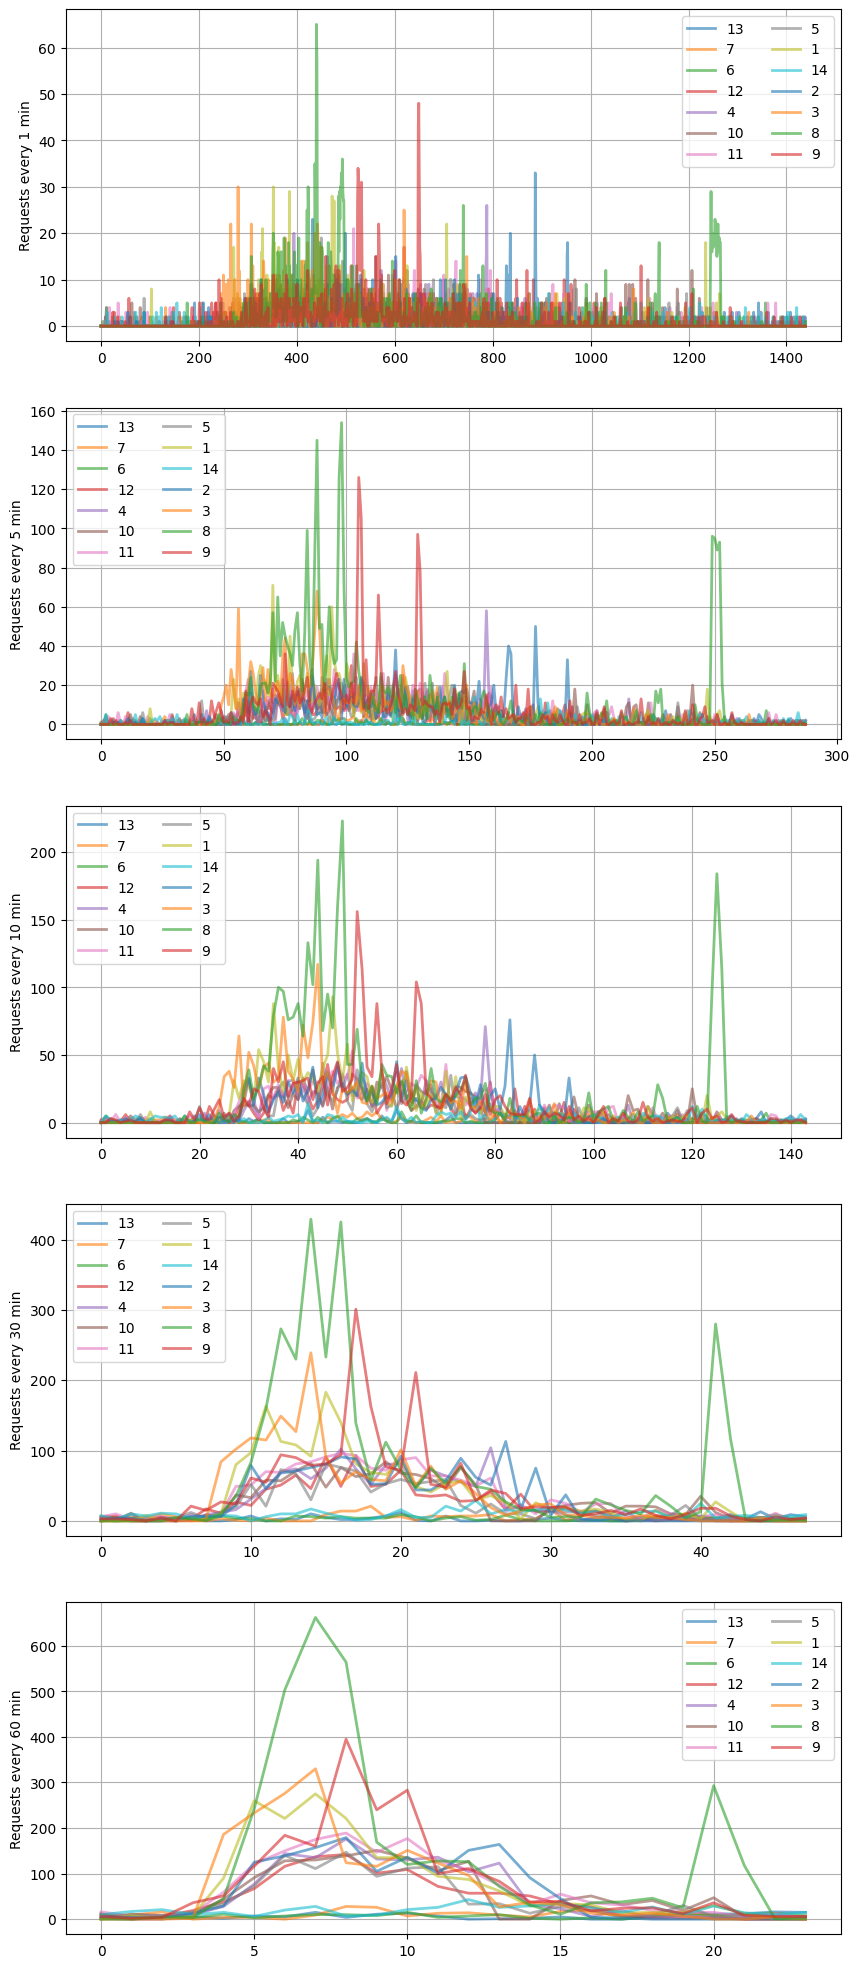

In [197]:
fid_invocations_grouped = {}
for window in [1, 5, 10, 30, 60]:
  fid_invocations_grouped[window] = {}
  for day in fid_invocations:
    fid_invocations_grouped[window][day] = [
      sum(fid_invocations[day][i*window:(i+1)*window]) 
        for i in range(int(len(fid_invocations)/window))
    ]
  fid_invocations_grouped[window] = pd.DataFrame(
    fid_invocations_grouped[window]
  )

_, axs = plt.subplots(
  nrows = 5,
  ncols = 1,
  figsize = (10, 25)
)
idx = 0
for window, window_data in fid_invocations_grouped.items():
  window_data.plot(
    alpha = 0.6, 
    linewidth = 2,
    ax = axs[idx],
    # legend = False,
    grid = True
  )
  axs[idx].set_ylabel(f"Requests every {window} min")
  axs[idx].legend(ncol = 2)
  idx += 1
plt.show()

# fid_invocations.rolling(window = 60, min_periods = 60).sum().plot(alpha = 0.6, linewidth = 2)
# plt.show()

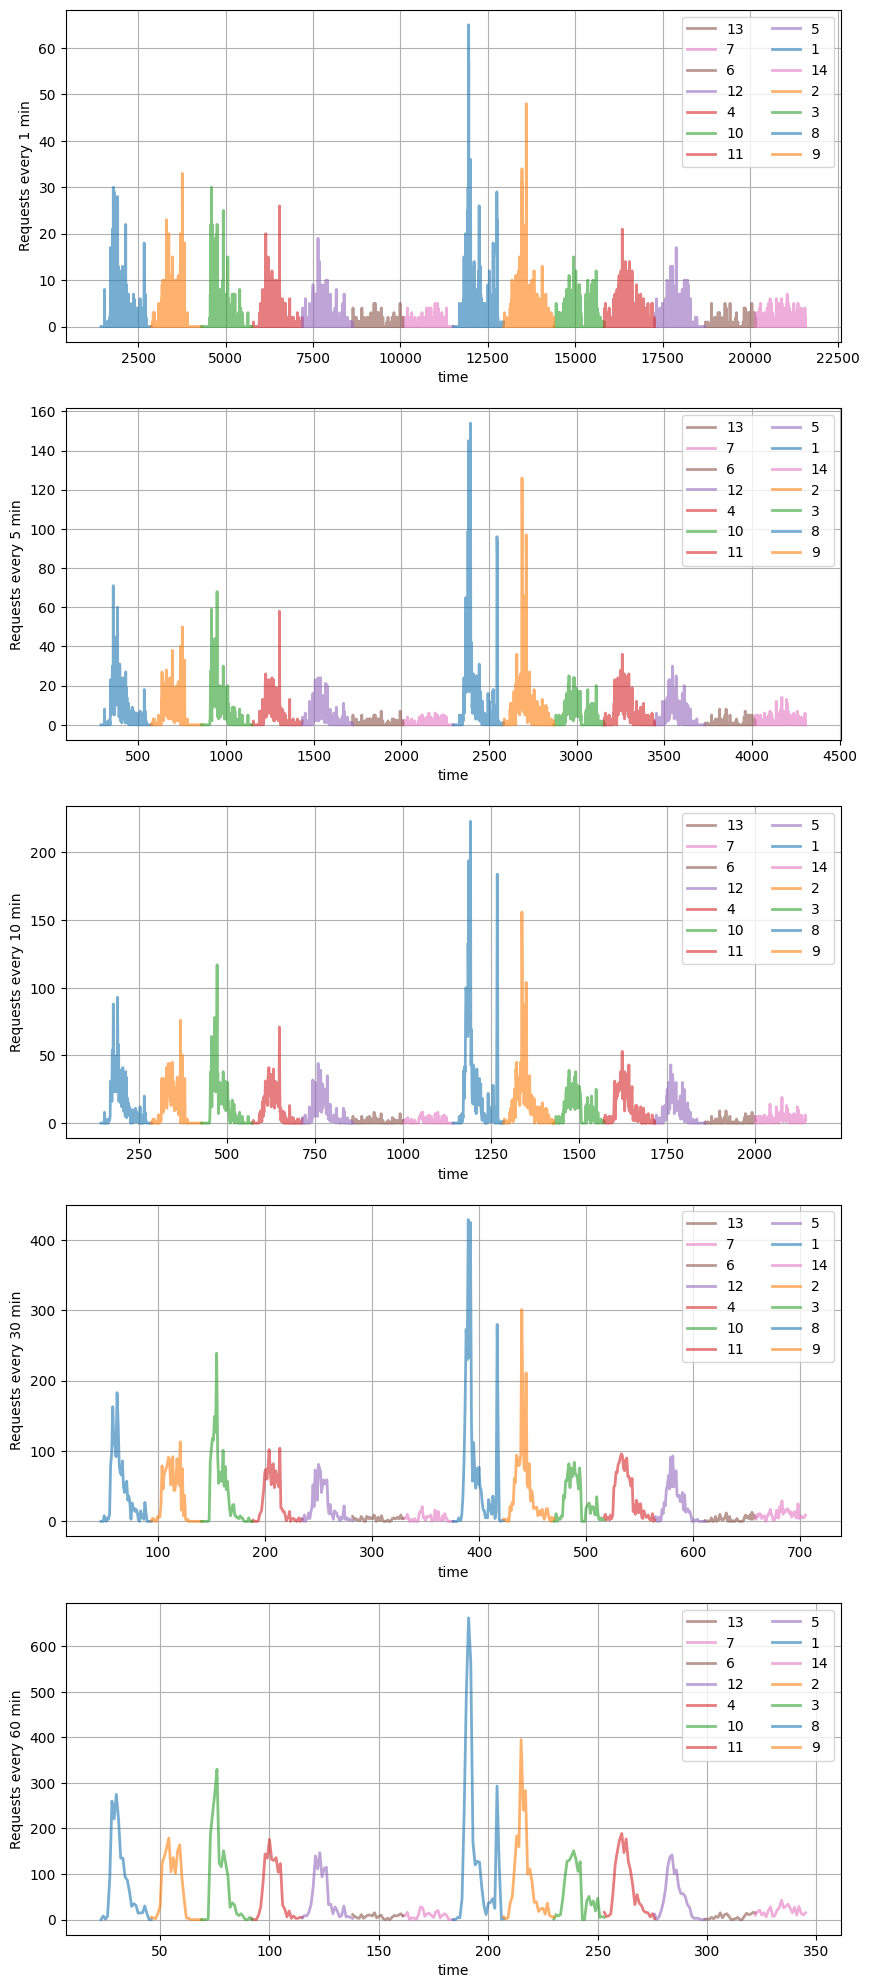

In [202]:
fid_invocations_grouped = {}
for window in [1, 5, 10, 30, 60]:
  fid_invocations_grouped[window] = {}
  for day in fid_invocations:
    fid_invocations_grouped[window][day] = [
      sum(fid_invocations[day][i*window:(i+1)*window]) 
        for i in range(int(len(fid_invocations)/window))
    ]
  fid_invocations_grouped[window] = pd.DataFrame(
    fid_invocations_grouped[window]
  )

colors = list(mcolors.TABLEAU_COLORS.values())[:7] * 2
_, axs = plt.subplots(
  nrows = 5,
  ncols = 1,
  figsize = (10, 25)
)
idx = 0
for window, window_data in fid_invocations_grouped.items():
  for day in window_data.columns:
    to_plot = pd.DataFrame(window_data[day].copy(deep = True))
    to_plot["time"] = to_plot.index + day * to_plot.index.max()
    to_plot.plot(
      x = "time",
      y = day,
      alpha = 0.6, 
      linewidth = 2,
      ax = axs[idx],
      color = colors[day - 1],
      # legend = False,
      grid = True
    )
  axs[idx].set_ylabel(f"Requests every {window} min")
  axs[idx].legend(ncol = 2)
  idx += 1
plt.show()

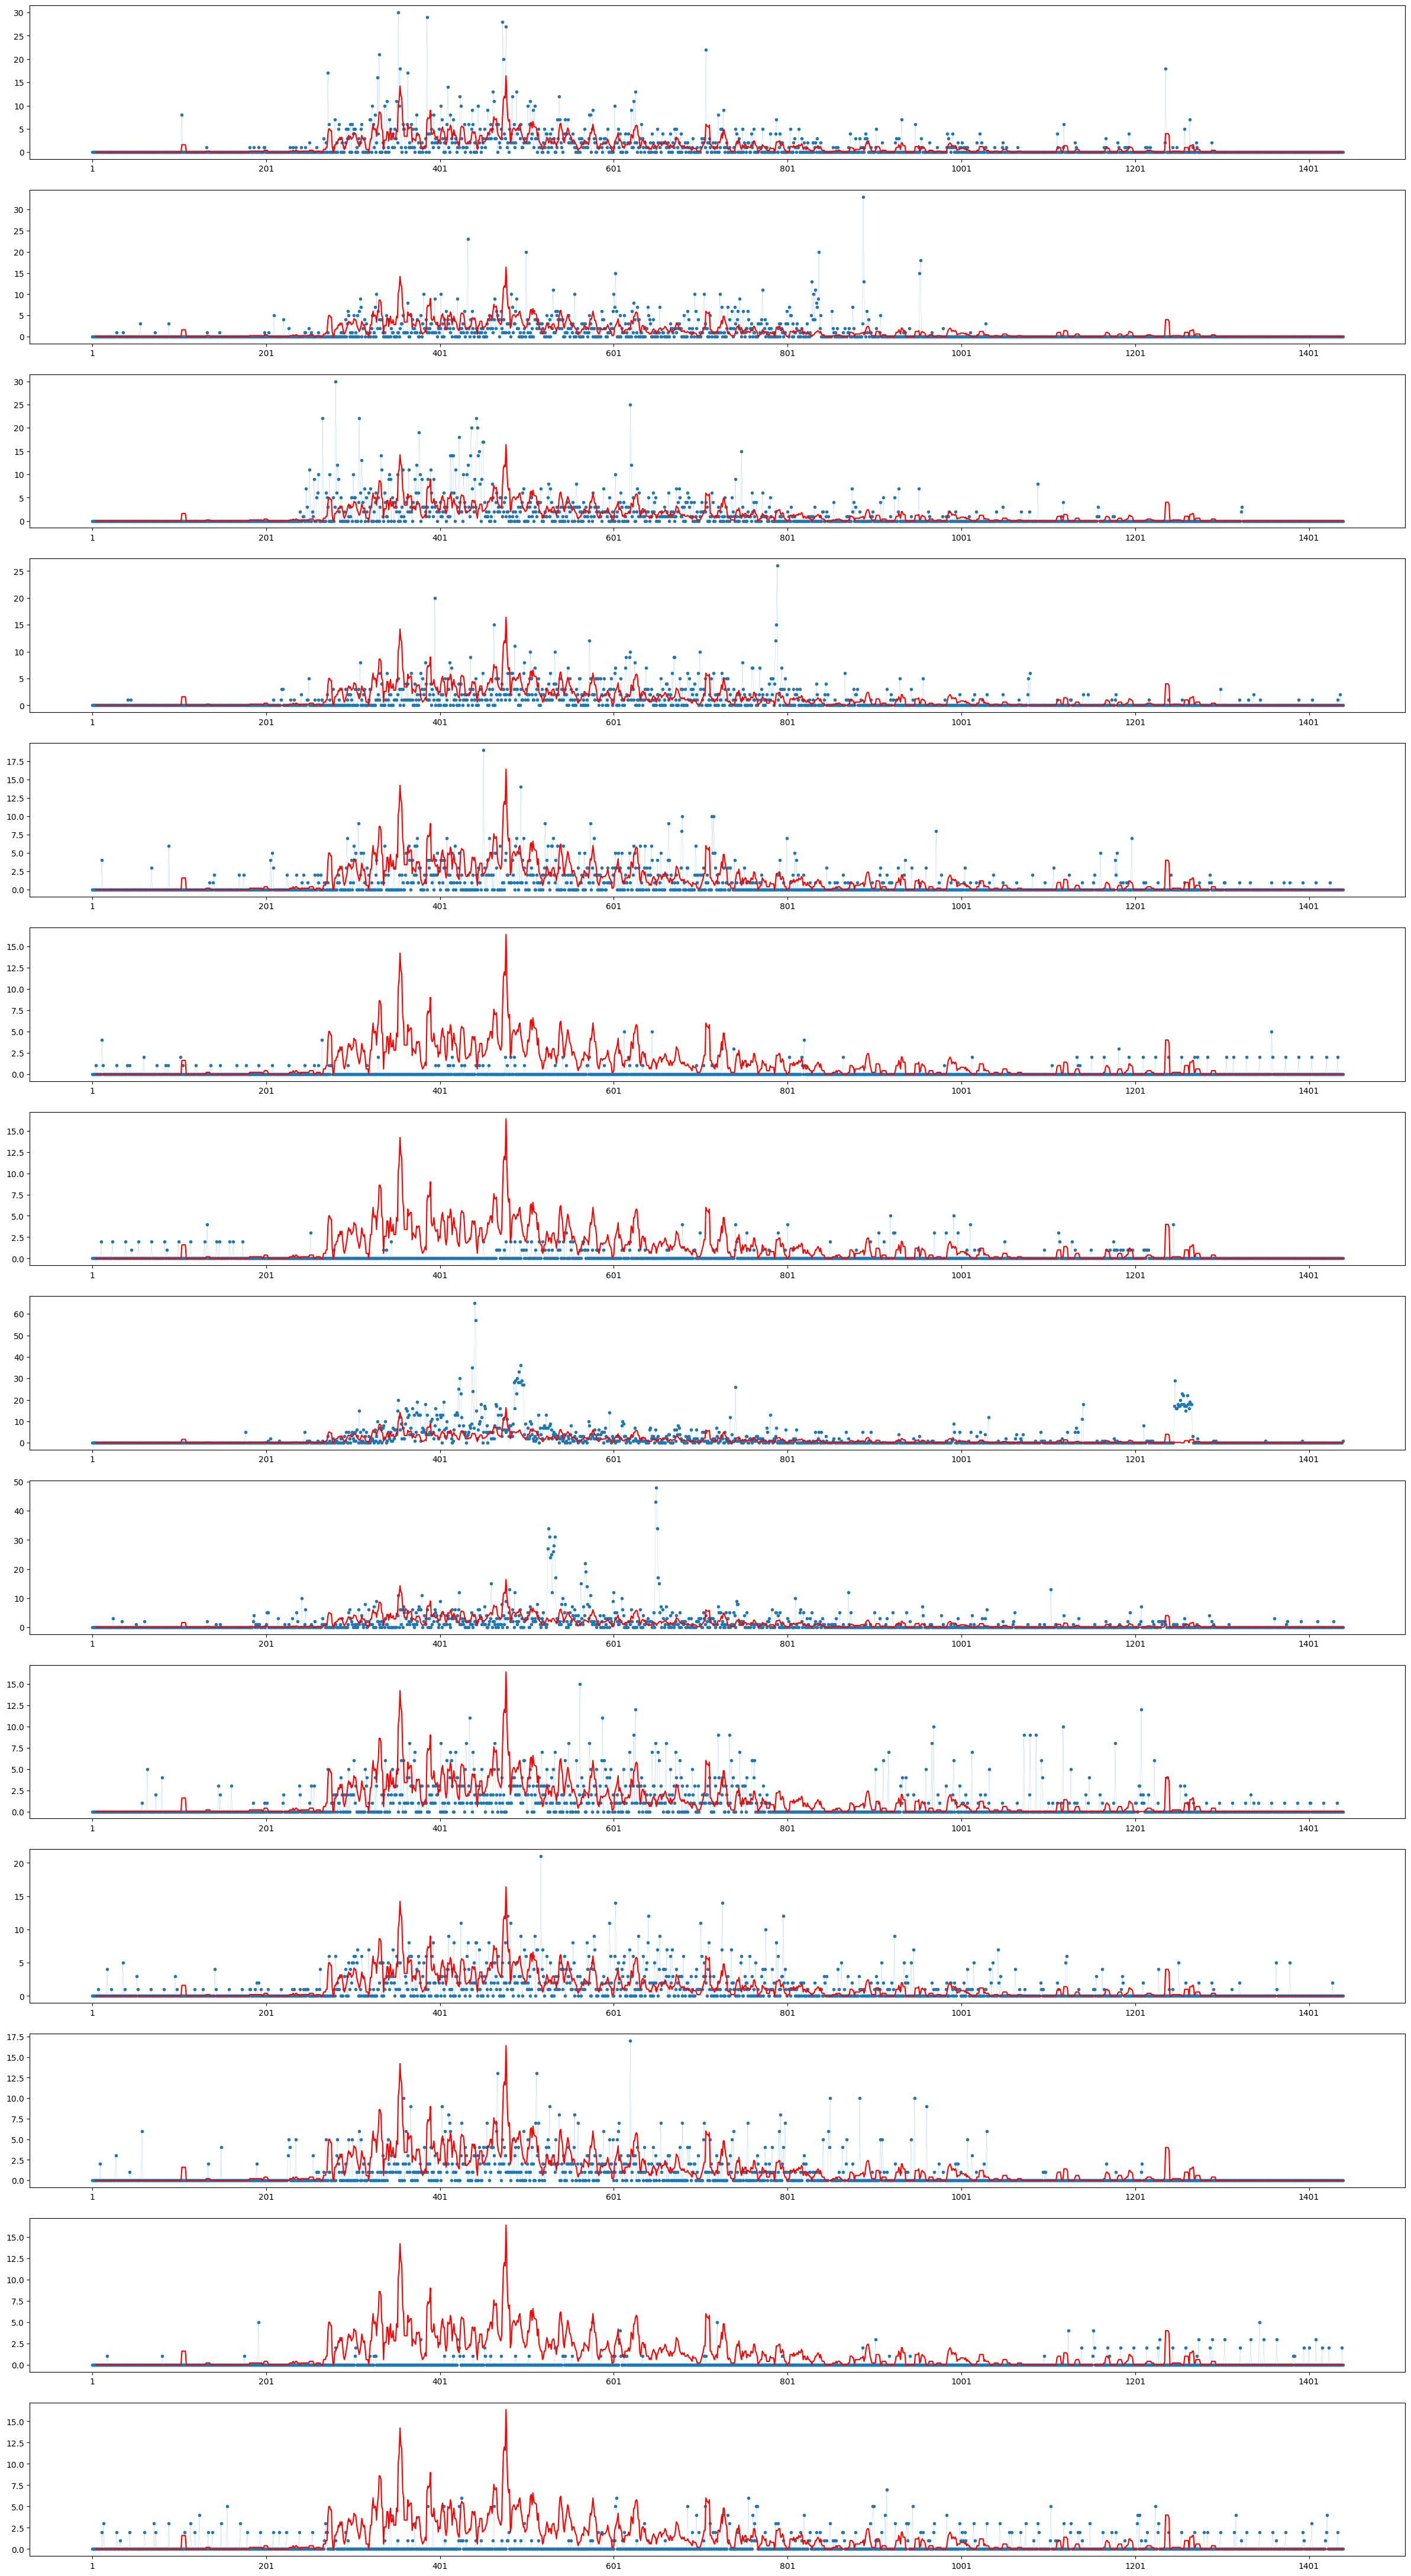

In [64]:
_, axs = plt.subplots(nrows = 14, ncols = 1, figsize = (30,4 * 14))
for day in range(1,15):
  avg = fid_invocations[1].rolling(window = 5).mean()
  fid_invocations[day].plot(marker = ".", linewidth = 0.1, ax = axs[day-1])
  avg.plot(color = "red", ax = axs[day-1])

In [65]:
alldays_functions_df = pd.DataFrame()
if os.path.exists(os.path.join(data_folder, "alldays_functions.csv")):
  alldays_functions_df = pd.read_csv(
    os.path.join(data_folder, "alldays_functions.csv")
  )
else:
  alldays_functions_df = http_data.set_index("HashFunction").loc[
    alldays_functions
  ]
  alldays_functions_df.to_csv(
    os.path.join(data_folder, "alldays_functions.csv")
  )
alldays_functions_df.describe()

,1,2,3,4,5,6,7,8,9,10,...,1432,1433,1434,1435,1436,1437,1438,1439,1440,DAY
count,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,...,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000,89390.000000
mean,23.505191,20.406611,19.353910,20.173375,19.561316,19.734433,19.351102,19.333281,19.241224,19.031357,...,18.828784,18.525036,19.161215,18.775847,19.176138,19.064560,18.831458,18.815371,18.503188,7.500000
std,933.698073,777.296869,749.058587,767.043364,731.897636,731.300034,747.250553,759.589108,747.729042,750.682670,...,768.300929,744.238953,761.816685,731.979205,736.697294,755.994761,759.274982,747.191425,751.502508,4.031151
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.500000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000
max,75217.000000,65324.000000,60724.000000,61957.000000,60878.000000,59370.000000,63283.000000,61412.000000,60450.000000,62496.000000,...,64841.000000,60062.000000,61541.000000,60310.000000,60140.000000,63306.000000,61661.000000,60447.000000,61655.000000,14.000000


In [66]:
alldays_functions_df

,HashFunction,HashOwner,HashApp,Trigger,1,2,3,4,5,6,...,1432,1433,1434,1435,1436,1437,1438,1439,1440,DAY
0,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1e6aa0ace3f2c0df114126e303bd6c84343690c7bb3634...,d0c1af9d7aa9c97fc6495af1a7283f3d1799ce13868623...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,13
1,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1e6aa0ace3f2c0df114126e303bd6c84343690c7bb3634...,d0c1af9d7aa9c97fc6495af1a7283f3d1799ce13868623...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
2,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1e6aa0ace3f2c0df114126e303bd6c84343690c7bb3634...,d0c1af9d7aa9c97fc6495af1a7283f3d1799ce13868623...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
3,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1e6aa0ace3f2c0df114126e303bd6c84343690c7bb3634...,d0c1af9d7aa9c97fc6495af1a7283f3d1799ce13868623...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12
4,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1e6aa0ace3f2c0df114126e303bd6c84343690c7bb3634...,d0c1af9d7aa9c97fc6495af1a7283f3d1799ce13868623...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89385,fff7862e80476cf8e355d27b856679f5bda38161b1d52d...,dcc221062c4b0a281b332a48dd98b53e609ceda743d2e6...,01857570bb7d57960c0369c93e53f2cd9577226229a443...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,14
89386,fff7862e80476cf8e355d27b856679f5bda38161b1d52d...,dcc221062c4b0a281b332a48dd98b53e609ceda743d2e6...,01857570bb7d57960c0369c93e53f2cd9577226229a443...,http,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2
89387,fff7862e80476cf8e355d27b856679f5bda38161b1d52d...,dcc221062c4b0a281b332a48dd98b53e609ceda743d2e6...,01857570bb7d57960c0369c93e53f2cd9577226229a443...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
89388,fff7862e80476cf8e355d27b856679f5bda38161b1d52d...,dcc221062c4b0a281b332a48dd98b53e609ceda743d2e6...,01857570bb7d57960c0369c93e53f2cd9577226229a443...,http,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,8


In [86]:
# count owners
alldays_functions_df.groupby("HashOwner").ngroups

2598

In [ ]:
all_invocations = pd.DataFrame()
if os.path.exists(
    os.path.join(data_folder, f"alldays_http_invocations_{time_window}min.csv")
  ):
  all_invocations = pd.read_csv(
    os.path.join(data_folder, f"alldays_http_invocations_{time_window}min.csv")
  )
else:
  for (owner, app), oa_functions in alldays_functions_df.groupby(
      ["HashOwner", "HashApp"]
    ):
    for fid, oaid_data in oa_functions.groupby("HashFunction"):
      # extract invocations
      oaid_invocations = oaid_data.set_index("DAY")[
        [str(i) for i in range(1,1441)]
      ].transpose()
      # group by window
      oaid_invocations_grouped = {}
      for day in oaid_invocations:
        oaid_invocations_grouped[day] = [
          sum(oaid_invocations[day][i*time_window:(i+1)*time_window]) 
            for i in range(int(len(oaid_invocations)/time_window))
        ]
      oaid_invocations_grouped = pd.DataFrame(oaid_invocations_grouped)
      # add hash information
      l = len(oaid_invocations_grouped)
      oaid_invocations_grouped["HashOwner"] = [owner] * l
      oaid_invocations_grouped["HashApp"] = [app] * l
      oaid_invocations_grouped["HashFunction"] = [fid] * l
      oaid_invocations_grouped["time"] = oaid_invocations_grouped.index
      # concat
      all_invocations = pd.concat(
        [all_invocations, oaid_invocations_grouped], ignore_index = True
      )
  # save
  all_invocations.to_csv(
    os.path.join(data_folder, f"alldays_http_invocations_{time_window}min.csv"), 
    index = False
  )

In [88]:
all_invocations

,13,7,6,12,4,10,11,5,1,14,2,3,8,9,HashOwner,HashApp,HashFunction,time
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,00120a3b2acd94c5dab17ee482c500a76294c4e54fe32e...,5151a3e2694a55b3c2c8e6373f7f731ffb510bbbf36611...,c42de74e2dd1b922a8e2319a6c7e513ee4cd91f8766020...,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,00120a3b2acd94c5dab17ee482c500a76294c4e54fe32e...,5151a3e2694a55b3c2c8e6373f7f731ffb510bbbf36611...,c42de74e2dd1b922a8e2319a6c7e513ee4cd91f8766020...,1
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,00120a3b2acd94c5dab17ee482c500a76294c4e54fe32e...,5151a3e2694a55b3c2c8e6373f7f731ffb510bbbf36611...,c42de74e2dd1b922a8e2319a6c7e513ee4cd91f8766020...,2
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,00120a3b2acd94c5dab17ee482c500a76294c4e54fe32e...,5151a3e2694a55b3c2c8e6373f7f731ffb510bbbf36611...,c42de74e2dd1b922a8e2319a6c7e513ee4cd91f8766020...,3
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,00120a3b2acd94c5dab17ee482c500a76294c4e54fe32e...,5151a3e2694a55b3c2c8e6373f7f731ffb510bbbf36611...,c42de74e2dd1b922a8e2319a6c7e513ee4cd91f8766020...,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612955,1,1,1,1,1,1,1,1,1,1,1,1,1,1,ffdd3d1c6a84caf0b741293bfac9d0d9c6445b53dfc294...,4070b1f96eb6f0c01f72134b4f08efda402b9cdffdd85d...,43db8355f80b8775d137d00fb1ef11a4d6c2bb1f8a1f4f...,91
612956,1,1,1,1,1,1,1,1,1,1,1,1,1,1,ffdd3d1c6a84caf0b741293bfac9d0d9c6445b53dfc294...,4070b1f96eb6f0c01f72134b4f08efda402b9cdffdd85d...,43db8355f80b8775d137d00fb1ef11a4d6c2bb1f8a1f4f...,92
612957,1,1,1,1,1,1,1,1,1,1,1,1,1,1,ffdd3d1c6a84caf0b741293bfac9d0d9c6445b53dfc294...,4070b1f96eb6f0c01f72134b4f08efda402b9cdffdd85d...,43db8355f80b8775d137d00fb1ef11a4d6c2bb1f8a1f4f...,93
612958,1,1,1,1,1,1,1,1,1,1,1,1,1,1,ffdd3d1c6a84caf0b741293bfac9d0d9c6445b53dfc294...,4070b1f96eb6f0c01f72134b4f08efda402b9cdffdd85d...,43db8355f80b8775d137d00fb1ef11a4d6c2bb1f8a1f4f...,94


In [89]:
fid = alldays_functions[500]
fid

'142fd859b4b21a2906c44711b6cadc540f56df771c2798bac17be9d68e80d096'

<Axes: xlabel='time'>

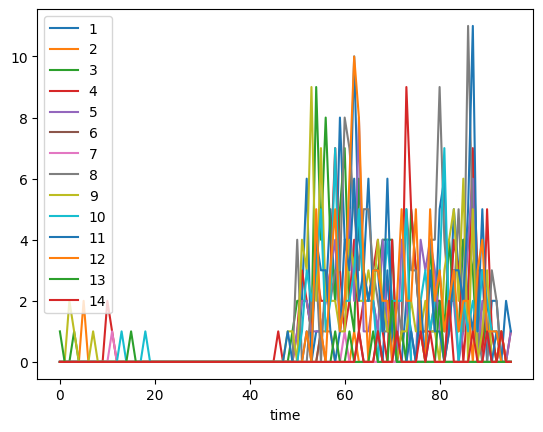

In [90]:
all_invocations[all_invocations["HashFunction"] == fid][
  ["time"] + list(range(1,15))
].plot(
  x = "time"
)

In [91]:
def compute_statistics(data: pd.DataFrame, groupkey: str) -> pd.DataFrame:
  all_stats = pd.DataFrame()
  for _, grouped_data in data.groupby(groupkey):
    df = grouped_data[
      list(range(1,15))
    ].rename(columns = {k: f"req{k}" for k in range(1,15)})
    idx = df.index
    df["idx"] = idx
    df = pd.wide_to_long(df, stubnames = ["req"], i = "idx", j = "day")
    # compute statistics
    stats = pd.DataFrame(df.describe()).transpose()
    stats["idx_min"] = min(idx)
    stats["idx_max"] = max(idx)
    # merge
    all_stats = pd.concat([all_stats, stats], ignore_index = True)
  return all_stats

In [ ]:
def flatten_invocations(data: pd.DataFrame, groupkey: str) -> pd.DataFrame:
  flat_invocations = pd.DataFrame()
  for fid, basedf in data.groupby(groupkey):
    # concatenate days
    df = basedf[list(range(1,15))].rename(
      columns = {k: f"req{k}" for k in range(1,15)}
    )
    df["fid"] = [fid] * len(df)
    df["hour"] = range(1, len(df) + 1)
    onecol_df = pd.wide_to_long(
      df, stubnames = ["req"], i = ["fid", "hour"], j = "day"
    )
    # merge
    flat_invocations = pd.concat(
      [flat_invocations, onecol_df.reset_index()], ignore_index = True
    )
  return flat_invocations

### Consider separate function IDs

In [12]:
# get distribution
all_stats = compute_statistics(all_invocations, "HashFunction")

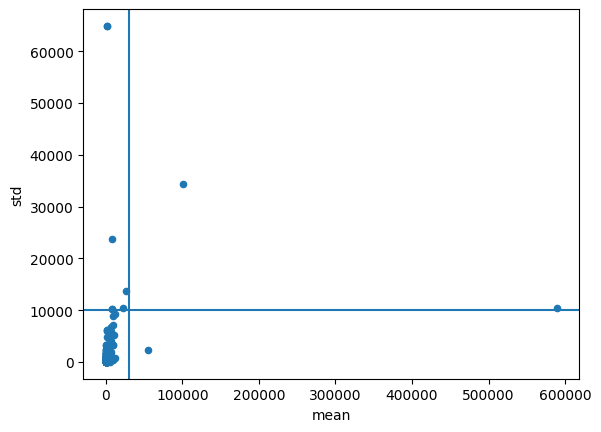

In [17]:
ax = all_stats[["mean", "std"]].plot.scatter(x="mean", y="std")
ax.axhline(y = 10000)
ax.axvline(x = 0.3e5)

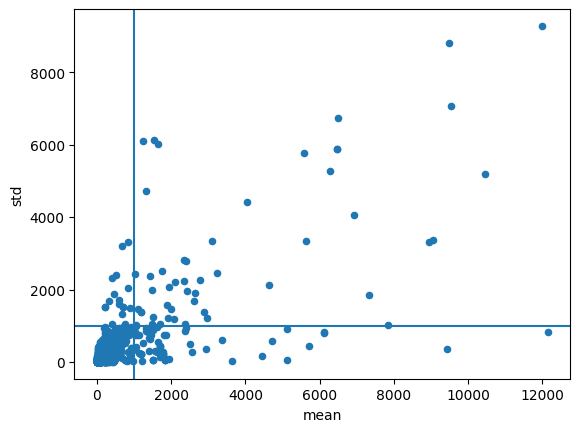

In [20]:
ax = all_stats[
  (all_stats["std"] < 10000) & (all_stats["mean"] < 0.5e5)
][["mean", "std"]].plot.scatter(x="mean", y="std")
ax.axhline(y = 1000)
ax.axvline(x = 1000)


,idx_min,idx_max
0,115056,115199
1,318240,318383
2,614736,614879
3,414288,414431
5,388944,389087
...,...,...
6380,669888,670031
6381,394704,394847
6382,199440,199583
6383,482976,483119


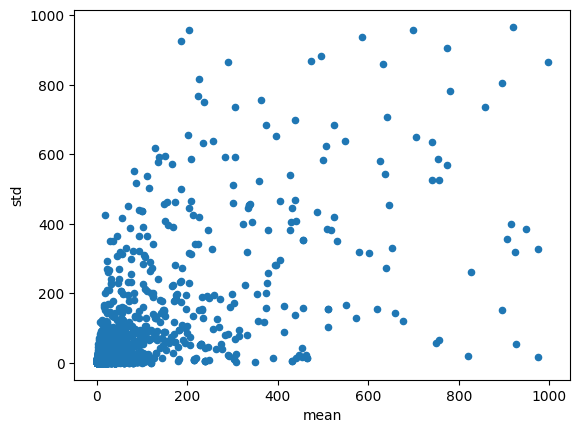

In [21]:
ax = all_stats[
  (all_stats["std"] < 1000) & (all_stats["mean"] < 1000)
][["mean", "std"]].plot.scatter(x="mean", y="std")

valid_idx_boundaries = all_stats[
  (all_stats["std"] < 1000) & (all_stats["mean"] < 1000)
][["idx_min", "idx_max"]]
valid_idx_boundaries

In [22]:
# filter invocations based on the selected indices
valid_idxs = []
for i in range(len(valid_idx_boundaries)):
  idx_min = valid_idx_boundaries.iloc[i]["idx_min"]
  idx_max = valid_idx_boundaries.iloc[i]["idx_max"]
  valid_idxs += list(range(idx_min, idx_max + 1))

filtered_invocations = all_invocations.loc[valid_idxs]
len(filtered_invocations)

899280

In [169]:
# flatten invocations
flat_invocations = flatten_invocations(filtered_invocations, "HashFunction")
flat_invocations.to_csv(
  os.path.join(data_folder, f"flat_invocations_{time_window}min.csv"), 
  index = False
)
flat_invocations

,fid,hour,day,req
0,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1,1,1
1,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1,2,1
2,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1,3,1
3,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1,4,1
4,0001f8e959dcdff9098d97c72e9184e8b814ddd06f4c88...,1,5,1
...,...,...,...,...
2098987,fff7862e80476cf8e355d27b856679f5bda38161b1d52d...,24,10,19
2098988,fff7862e80476cf8e355d27b856679f5bda38161b1d52d...,24,11,11
2098989,fff7862e80476cf8e355d27b856679f5bda38161b1d52d...,24,12,46
2098990,fff7862e80476cf8e355d27b856679f5bda38161b1d52d...,24,13,17


### Aggregate by owner

In [93]:
# sum over all functions from each owner
all_invocations["HashApp"] += "-"
all_invocations["HashFunction"] += "-"
by_owner_invocations = all_invocations.groupby(["HashOwner", "time"]).sum()

by_owner_invocations#.reset_index()

13     7     6  \
HashOwner                                          time                     
00120a3b2acd94c5dab17ee482c500a76294c4e54fe32eb... 0     2482  2721  3081   
                                                   1     2404  2783  3034   
                                                   2     2433  2773  3083   
                                                   3     2342  2805  3038   
                                                   4     2547  2866  3164   
...                                                       ...   ...   ...   
ffdd3d1c6a84caf0b741293bfac9d0d9c6445b53dfc2941... 91       1     1     1   
                                                   92       1     1     1   
                                                   93       1     1     1   
                                                   94       1     1     1   
                                                   95       1     1     1   

                                                           12     4    10  \
HashOwner                                          time                     
00120a3b2acd94c5dab17ee482c500a76294c4e54fe32eb... 0     3048  3222  3107   
                                                   1     3025  3233  3079   
                                                   2     3031  3255  3065   
                                                   3     3000  3241  3038   
                                                   4     3292  3348  3307   
...                                                       ...   ...   ...   
ffdd3d1c6a84caf0b741293bfac9d0d9c6445b53dfc2941... 91       1     1     1   
                                                   92       1     1     1   
                                                   93       1     1     1   
                                                   94       1     1     1   
                                                   95       1     1     1   

                                                           11     5     1  \
HashOwner                                          time                     
00120a3b2acd94c5dab17ee482c500a76294c4e54fe32eb... 0     3146  3186  3086   
                                                   1     3050  3138  3046   
                                                   2     3030  3195  3071   
                                                   3     3035  3127  3032   
                                                   4     3348  3239  3210   
...                                                       ...   ...   ...   
ffdd3d1c6a84caf0b741293bfac9d0d9c6445b53dfc2941... 91       1     1     1   
                                                   92       1     1     1   
                                                   93       1     1     1   
                                                   94       1     1     1   
                                                   95       1     1     1   

                                                           14     2     3  \
HashOwner                                          time                     
00120a3b2acd94c5dab17ee482c500a76294c4e54fe32eb... 0     2186  3105  3470   
                                                   1     2154  3119  3426   
                                                   2     2122  3110  3432   
                                                   3     2108  3116  3460   
                                                   4     2310  3251  3516   
...                                                       ...   ...   ...   
ffdd3d1c6a84caf0b741293bfac9d0d9c6445b53dfc2941... 91       1     1     1   
                                                   92       1     1     1   
                                                   93       1     1     1   
                                                   94       1     1     1   
                                                   95       1     1     1   

                                                   

In [94]:
bo_stats = compute_statistics(by_owner_invocations.reset_index(), "HashOwner")
bo_stats

,count,mean,std,min,25%,50%,75%,max,idx_min,idx_max
0,1344.0,2340.597470,470.348181,1524.0,1933.0,2194.5,2737.50,3516.0,0,95
1,1344.0,1.267857,1.550244,0.0,0.0,1.0,2.00,6.0,96,191
2,1344.0,5.915923,10.791999,0.0,0.0,1.0,8.00,112.0,192,287
3,1344.0,0.714286,2.053688,0.0,0.0,0.0,0.00,23.0,288,383
4,1344.0,3.666667,1.700306,2.0,3.0,3.0,3.00,19.0,384,479
...,...,...,...,...,...,...,...,...,...,...
2593,1344.0,5.994792,0.130762,2.0,6.0,6.0,6.00,7.0,248928,249023
2594,1344.0,10.453125,10.899153,0.0,3.0,6.0,15.25,111.0,249024,249119
2595,1344.0,14.143601,7.970781,2.0,7.0,8.0,20.00,33.0,249120,249215
2596,1344.0,59.024554,0.725141,40.0,59.0,59.0,59.00,60.0,249216,249311


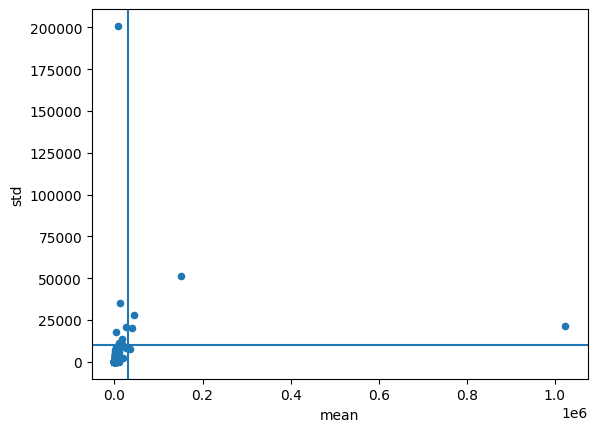

In [95]:
ax = bo_stats[["mean", "std"]].plot.scatter(x="mean", y="std")
ax.axhline(y = 10000)
ax.axvline(x = 0.3e5)

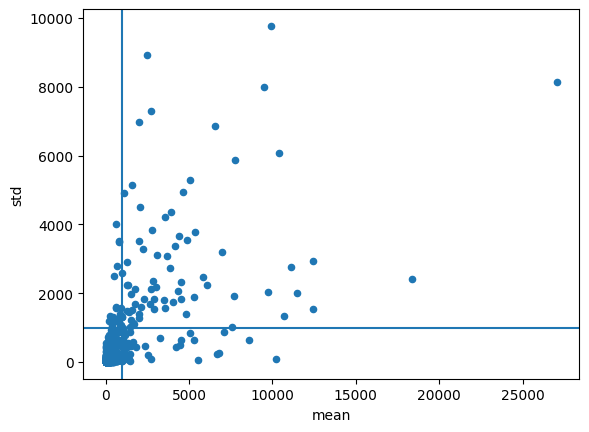

In [96]:
ax = bo_stats[
  (bo_stats["std"] < 10000) & (bo_stats["mean"] < 0.3e5)
][["mean", "std"]].plot.scatter(x="mean", y="std")
ax.axhline(y = 1000)
ax.axvline(x = 1000)

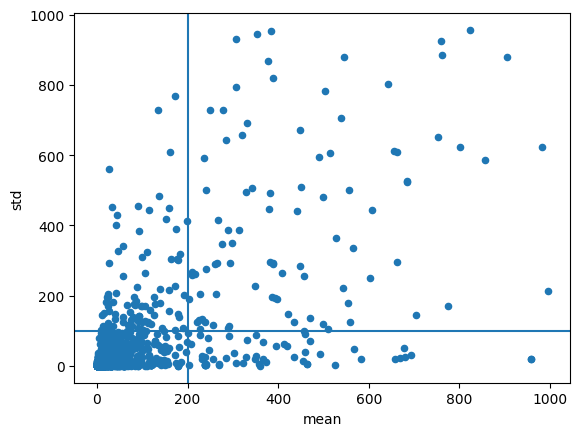

In [98]:
ax = bo_stats[
  (bo_stats["std"] < 1000) & (bo_stats["mean"] < 1000)
][["mean", "std"]].plot.scatter(x="mean", y="std")
ax.axhline(y = 100)
ax.axvline(x = 200)

,idx_min,idx_max
19,1824,1919
20,1920,2015
26,2496,2591
32,3072,3167
33,3168,3263
...,...,...
2587,248352,248447
2592,248832,248927
2594,249024,249119
2595,249120,249215


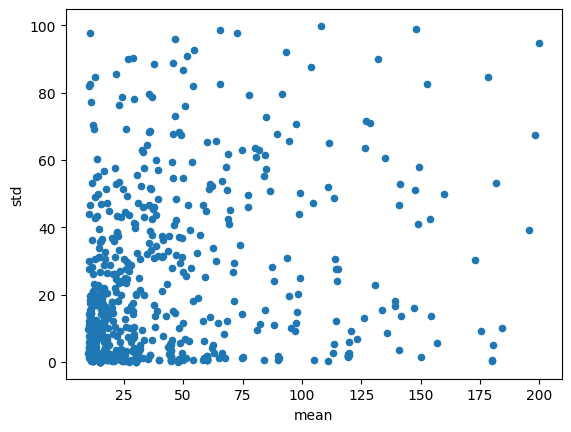

In [99]:
ax = bo_stats[
  (bo_stats["std"] < 100) & (bo_stats["mean"] < 200) & (bo_stats["mean"] > 10)
][["mean", "std"]].plot.scatter(x="mean", y="std")

valid_idx_boundaries = bo_stats[
  (bo_stats["std"] < 100) & (bo_stats["mean"] < 200) & (bo_stats["mean"] > 10)
][["idx_min", "idx_max"]]
valid_idx_boundaries

In [100]:
# filter invocations based on the selected indices
valid_idxs = []
for i in range(len(valid_idx_boundaries)):
  idx_min = valid_idx_boundaries.iloc[i]["idx_min"]
  idx_max = valid_idx_boundaries.iloc[i]["idx_max"]
  valid_idxs += list(range(idx_min, idx_max + 1))

by_owner_invocations = by_owner_invocations.reset_index()
filtered_invocations = by_owner_invocations.loc[valid_idxs]
len(filtered_invocations)

60576

In [101]:
# flatten invocations
bo_flat_invocations = flatten_invocations(filtered_invocations, "HashOwner")
bo_flat_invocations.to_csv(
  os.path.join(data_folder, f"by_owner_flat_invocations_{time_window}min.csv"), 
  index = False
)
bo_flat_invocations

,fid,hour,day,req
0,01e0a1e7f551ecfb2b42677d3dd15e3023ca70bc1cee58...,1,1,2
1,01e0a1e7f551ecfb2b42677d3dd15e3023ca70bc1cee58...,1,2,3
2,01e0a1e7f551ecfb2b42677d3dd15e3023ca70bc1cee58...,1,3,2
3,01e0a1e7f551ecfb2b42677d3dd15e3023ca70bc1cee58...,1,4,3
4,01e0a1e7f551ecfb2b42677d3dd15e3023ca70bc1cee58...,1,5,3
...,...,...,...,...
848059,ffadfa9308d4b130cf2e65daec075efb84befec9eee65e...,96,10,59
848060,ffadfa9308d4b130cf2e65daec075efb84befec9eee65e...,96,11,59
848061,ffadfa9308d4b130cf2e65daec075efb84befec9eee65e...,96,12,59
848062,ffadfa9308d4b130cf2e65daec075efb84befec9eee65e...,96,13,59


<Axes: >

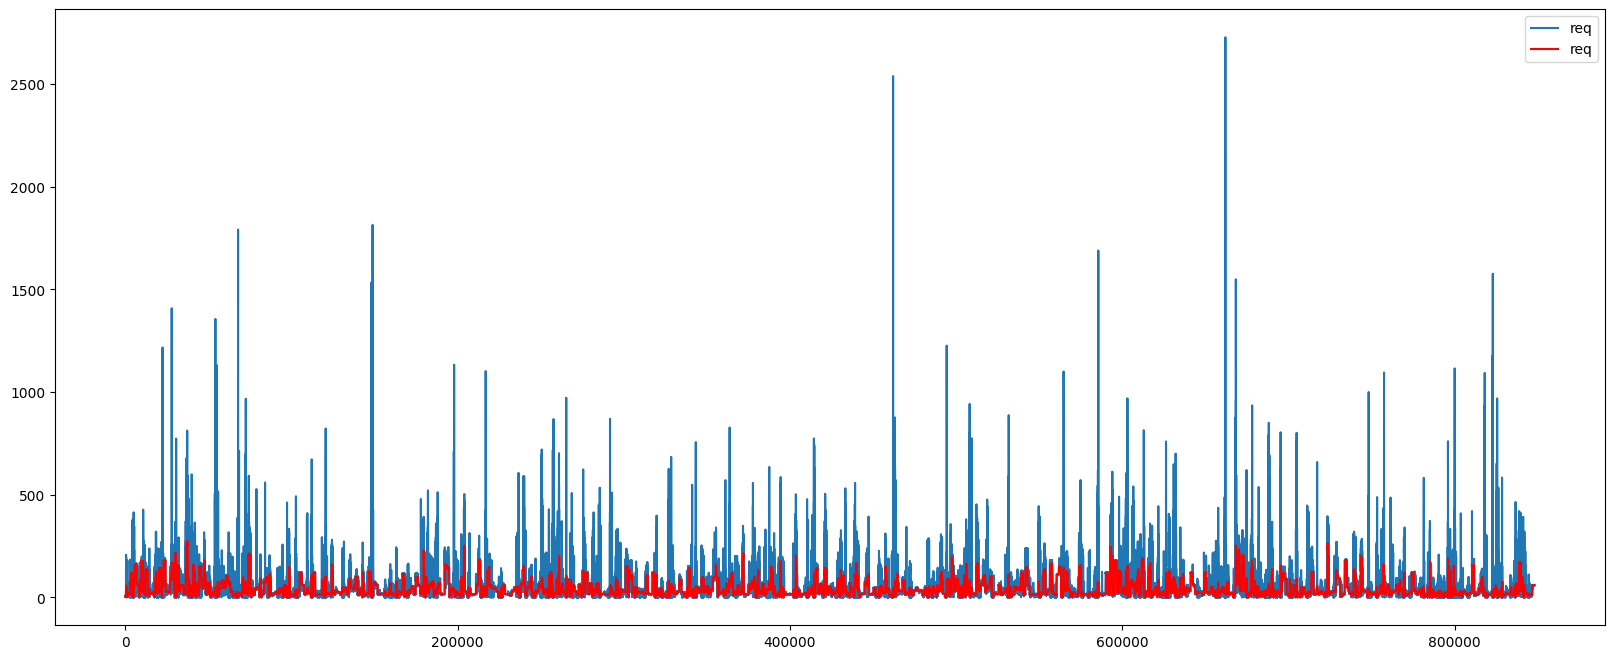

In [102]:
_, ax = plt.subplots(figsize = (20,8))
bo_flat_invocations.plot(y="req", ax = ax)
bo_flat_invocations.rolling(window = 144).mean(numeric_only=True).plot(
  y = "req",
  color = "r",
  ax = ax
)

In [103]:
len(filtered_invocations["HashOwner"].unique())

631

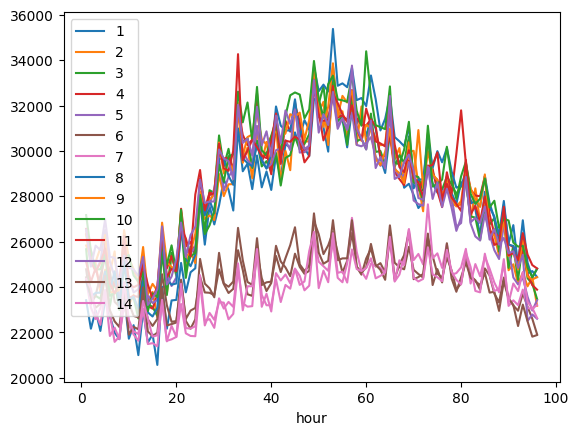

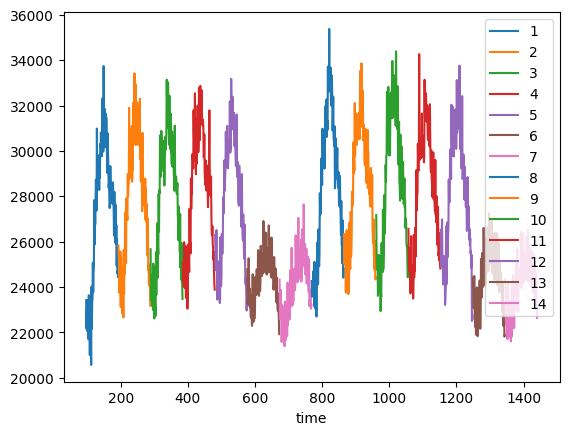

In [104]:
singlenode_req = bo_flat_invocations.groupby(["day", "hour"]).sum(
  numeric_only = True
)

colors = list(mcolors.TABLEAU_COLORS.values())[:7] * 2
_, ax1 = plt.subplots()
_, ax2 = plt.subplots()
for day, df1 in singlenode_req.groupby("day"):
  to_plot = df1.reset_index()
  to_plot.plot(
    x = "hour",
    y = "req",
    ax = ax1,
    label = day,
    color = colors[day - 1]
  )
  to_plot["time"] = to_plot["hour"] + day * to_plot["hour"].max()
  to_plot.plot(
    x = "time",
    y = "req",
    ax = ax2,
    label = day,
    color = colors[day - 1]
  )
# _, ax = plt.subplots(figsize = (20,8))
# bo_flat_invocations.plot(y="req", ax = ax)
# bo_flat_invocations.rolling(window = 144).mean(numeric_only=True).plot(
#   y = "req",
#   color = "r",
#   ax = ax
# )

In [314]:
req = alldays_functions_df.loc[
  alldays_functions_df["DAY"] == 1, [str(m) for m in range(1,1441)]
].transpose()
req.columns = [f"f{f}" for f in range(len(req.columns))]
req

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f6375,f6376,f6377,f6378,f6379,f6380,f6381,f6382,f6383,f6384
1,0,2,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,6,0,0,0,1,0,0,0,0,...,0,0,11,0,0,0,0,0,0,0
4,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
5,0,0,0,1,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1437,0,2,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
1438,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1439,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [317]:
req_stat = req.describe().transpose()
req_stat

,count,mean,std,min,25%,50%,75%,max
f0,1440.0,0.000694,0.026352,0.0,0.0,0.0,0.00,1.0
f1,1440.0,1.764583,2.606881,0.0,0.0,0.0,3.00,14.0
f2,1440.0,0.311111,0.548307,0.0,0.0,0.0,1.00,3.0
f3,1440.0,0.200000,0.400139,0.0,0.0,0.0,0.00,1.0
f4,1440.0,78.681250,434.658420,0.0,0.0,0.0,0.00,6321.0
...,...,...,...,...,...,...,...,...
f6380,1440.0,0.200000,0.400139,0.0,0.0,0.0,0.00,1.0
f6381,1440.0,1.334028,1.385503,0.0,0.0,1.0,2.00,8.0
f6382,1440.0,0.069444,0.522633,0.0,0.0,0.0,0.00,4.0
f6383,1440.0,0.250000,0.433163,0.0,0.0,0.0,0.25,1.0


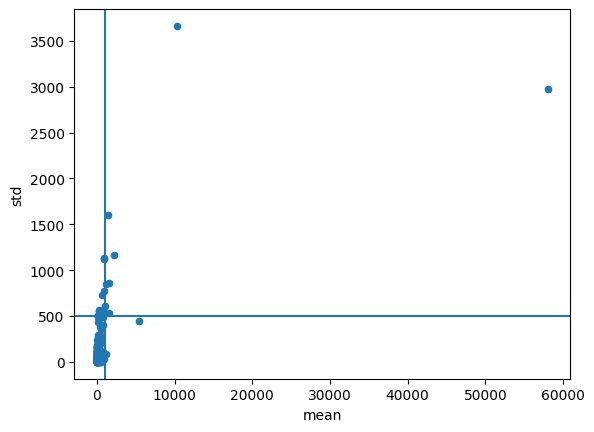

In [318]:
ax = req_stat.plot.scatter(x = "mean", y = "std")
ax.axvline(x = 1000)
ax.axhline(y = 500)

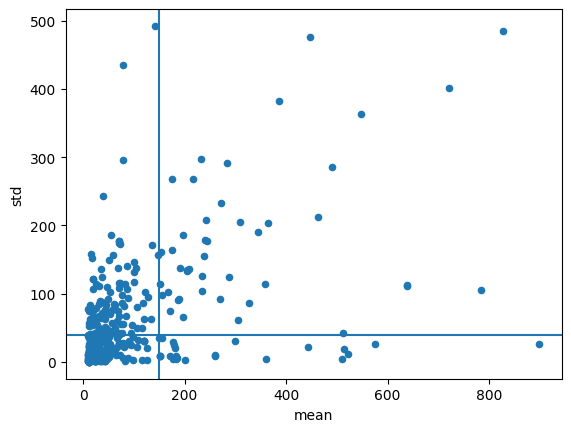

In [319]:
ax = req_stat[
  (req_stat["std"] < 500) & (req_stat["mean"] < 1000) & (req_stat["mean"] > 10)
].plot.scatter(x = "mean", y = "std")
ax.axvline(x = 150)
ax.axhline(y = 40)

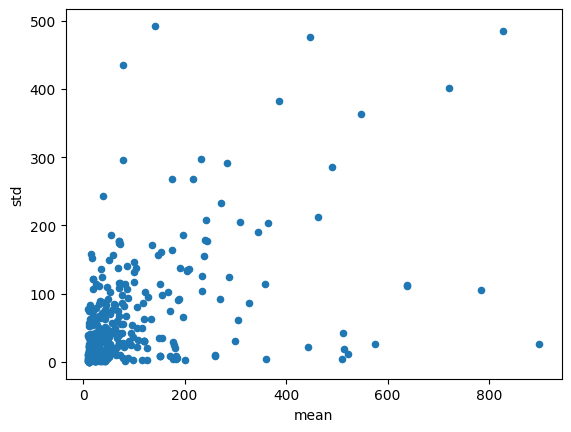

In [320]:
valid_functions = req_stat[
  # (req_stat["std"] < 50) & (req_stat["mean"] < 200) & (req_stat["mean"] > 10)
  (req_stat["std"] < 500) & (req_stat["mean"] < 1000) & (req_stat["mean"] > 10)
].index

ax = req_stat[
  # (req_stat["std"] < 50) & (req_stat["mean"] < 200) & (req_stat["mean"] > 10)
  (req_stat["std"] < 500) & (req_stat["mean"] < 1000) & (req_stat["mean"] > 10)
].plot.scatter(x="mean", y="std")

In [321]:
req = req.loc[:,valid_functions] + 1
req

,f4,f14,f16,f22,f46,f50,f81,f88,f144,f168,...,f6251,f6263,f6273,f6295,f6311,f6312,f6345,f6350,f6356,f6368
1,1,26,22,55,75,673,25,1,3,37,...,183,8,34,67,40,98,61,108,93,503
2,1,27,20,31,87,539,25,1,4,60,...,90,6,33,75,39,89,130,52,94,520
3,1,26,24,61,67,601,25,1,3,92,...,74,4,33,76,39,97,4,104,96,499
4,1,26,23,31,126,506,25,1,2,89,...,90,1,33,84,39,68,4,59,71,520
5,1,25,20,70,109,587,25,1,3,66,...,93,1,33,55,39,85,4,111,85,511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,1,26,20,25,97,556,25,1,2,360,...,106,1,34,122,40,146,61,42,148,489
1437,1,27,22,43,51,522,25,1,6,414,...,79,1,33,115,39,126,4,73,129,497
1438,1,25,23,28,87,573,25,1,1,363,...,88,1,33,113,39,140,4,37,135,497
1439,1,27,24,35,102,564,25,1,4,405,...,64,1,33,114,39,181,4,78,185,503


<Axes: >

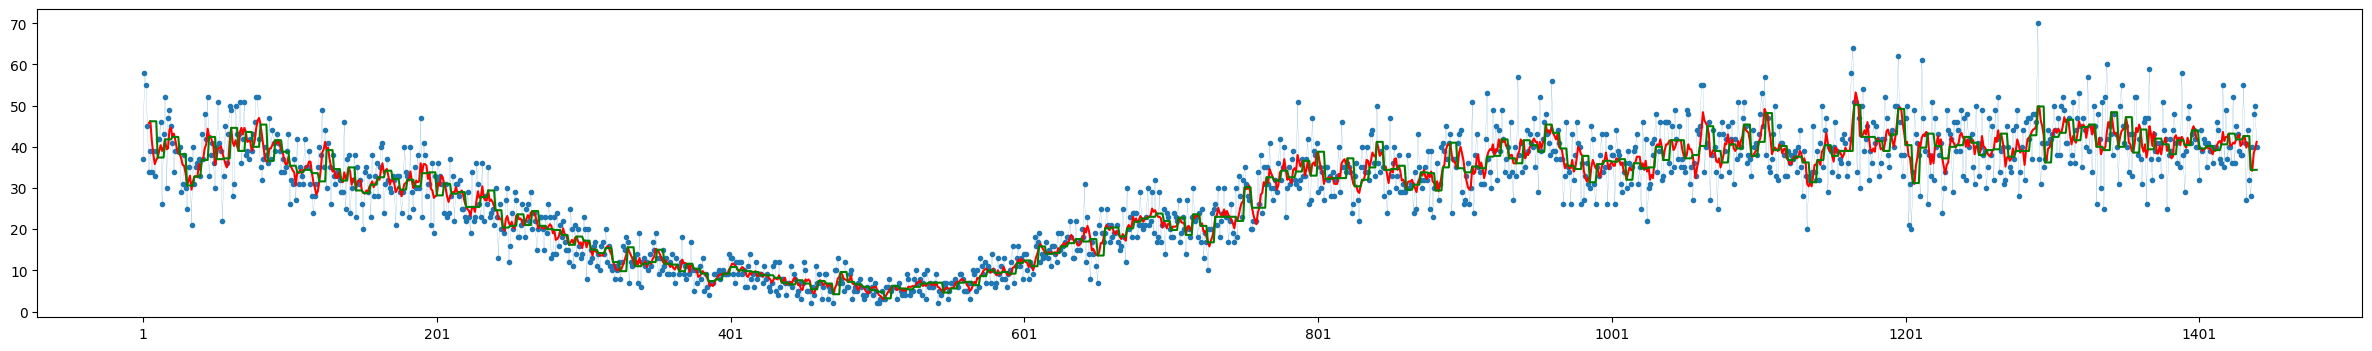

In [322]:
time_window = 5

moving_avg = req["f6188"].rolling(window = time_window).mean()
fixed_avg = np.repeat(
  req["f6188"].rolling(window = time_window, step = time_window).mean(), 
  time_window
)

_, ax = plt.subplots(figsize = (30,4))
req["f6188"].plot(marker = ".", linewidth = 0.1, ax = ax)
moving_avg.plot(color = "red", ax = ax)
fixed_avg.plot(color = "green", ax = ax)

In [323]:
fixed_avg_df = pd.DataFrame({
  funct: np.repeat(
    req[funct].rolling(
      window = time_window, step = time_window, min_periods = 0
    ).mean(), time_window
  ) for funct in req
})
fixed_avg_df.index = range(1, len(fixed_avg_df) + 1)
fixed_avg_df

,f4,f14,f16,f22,f46,f50,f81,f88,f144,f168,...,f6251,f6263,f6273,f6295,f6311,f6312,f6345,f6350,f6356,f6368
1,1.0,26.0,22.0,55.0,75.0,673.0,25.0,1.0,3.0,37.0,...,183.0,8.0,34.0,67.0,40.0,98.0,61.0,108.0,93.0,503.0
2,1.0,26.0,22.0,55.0,75.0,673.0,25.0,1.0,3.0,37.0,...,183.0,8.0,34.0,67.0,40.0,98.0,61.0,108.0,93.0,503.0
3,1.0,26.0,22.0,55.0,75.0,673.0,25.0,1.0,3.0,37.0,...,183.0,8.0,34.0,67.0,40.0,98.0,61.0,108.0,93.0,503.0
4,1.0,26.0,22.0,55.0,75.0,673.0,25.0,1.0,3.0,37.0,...,183.0,8.0,34.0,67.0,40.0,98.0,61.0,108.0,93.0,503.0
5,1.0,26.0,22.0,55.0,75.0,673.0,25.0,1.0,3.0,37.0,...,183.0,8.0,34.0,67.0,40.0,98.0,61.0,108.0,93.0,503.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,1.0,26.0,22.4,30.4,86.4,567.4,25.0,1.0,2.0,387.0,...,86.0,28.2,33.2,114.2,39.2,128.8,37.8,60.6,128.6,496.6
1437,1.0,26.0,22.4,30.4,86.4,567.4,25.0,1.0,2.0,387.0,...,86.0,28.2,33.2,114.2,39.2,128.8,37.8,60.6,128.6,496.6
1438,1.0,26.0,22.4,30.4,86.4,567.4,25.0,1.0,2.0,387.0,...,86.0,28.2,33.2,114.2,39.2,128.8,37.8,60.6,128.6,496.6
1439,1.0,26.0,22.4,30.4,86.4,567.4,25.0,1.0,2.0,387.0,...,86.0,28.2,33.2,114.2,39.2,128.8,37.8,60.6,128.6,496.6


In [324]:
errors = {
  "function": [],
  "rmse": [],
  "mae": [],
  "mape": [],
  # "cv": []
}
for f in req:
  errors["function"].append(f)
  errors["rmse"].append(
    ((req[f].values - fixed_avg_df[f].values) ** 2).mean() ** 0.5
  )
  errors["mae"].append(
    abs(req[f].values - fixed_avg_df[f].values).mean()
  )
  errors["mape"].append(
    (abs(req[f].values - fixed_avg_df[f].values) / req[f].values).mean()
  )
  # errors["cv"].append(
  #   errors["rmse"][-1] / fixed_avg_df[f].values
  # )
errors = pd.DataFrame(errors)
errors

,function,rmse,mae,mape
0,f4,351.883619,71.049167,9.182191
1,f14,1.141880,0.635833,0.025569
2,f16,3.590149,2.966944,0.133027
3,f22,12.327408,9.834167,0.657282
4,f46,15.370882,9.423194,0.524208
...,...,...,...,...
410,f6312,28.407980,21.764722,0.194695
411,f6345,66.939650,46.918472,6.038639
412,f6350,19.075825,16.348194,0.621381
413,f6356,28.426174,21.804861,0.194442


In [325]:
errors.describe()

,rmse,mae,mape
count,415.000000,415.000000,415.000000
mean,30.627136,14.907955,1.385537
std,46.626399,23.201565,3.863517
min,0.000000,0.000000,0.000000
25%,6.039243,3.746875,0.107411
50%,13.809533,7.964306,0.284910
75%,34.133808,16.357986,0.738930
max,356.069384,263.416111,41.006295


In [326]:
functions = errors[errors["mape"] > 0.3]["function"].values
len(functions) / len(errors)

0.4891566265060241

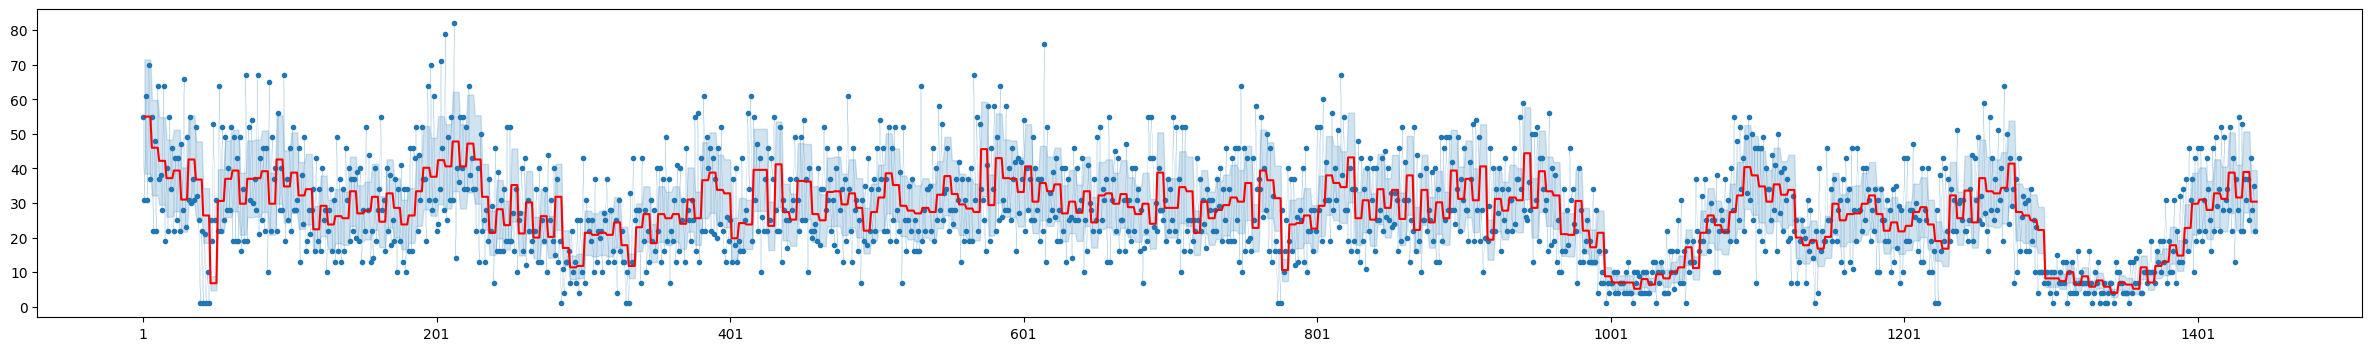

In [331]:
_, ax = plt.subplots(figsize = (30,4))
req[functions[1]].plot(marker = ".", linewidth = 0.1, ax = ax)
fixed_avg_df[functions[1]].plot(color = "red", ax = ax)
ax.fill_between(
  x = fixed_avg_df.index,
  y1 = fixed_avg_df[functions[1]] * 0.7, 
  y2 = fixed_avg_df[functions[1]] * 1.3,
  color = mcolors.TABLEAU_COLORS["tab:blue"],
  alpha = 0.2
)

In [332]:
errors[errors["function"] == functions[1]]

,function,rmse,mae,mape
3,f22,12.327408,9.834167,0.657282


#### Error considering "fixed" average

In [341]:
time_window = 5
all_errors = pd.DataFrame()
all_req = pd.DataFrame()
all_fixed_avg = pd.DataFrame()
for day in range(1,15): #list(range(1,6)) + list(range(8,13)):
  req = alldays_functions_df.loc[
    alldays_functions_df["DAY"] == day, [str(m) for m in range(1,1441)]
  ].transpose()
  req.columns = [f"f{f}" for f in range(len(req.columns))]
  # req_stat = req.describe().transpose()
  # valid_functions = req_stat[
  #   (req_stat["std"] < 500) & (req_stat["mean"] < 1000) & (req_stat["mean"] > 10)
  # ].index
  # req = req.loc[:,valid_functions] + 1
  req += 1
  fixed_avg_df = pd.DataFrame({
    funct: np.repeat(
      req[funct].rolling(
        window = time_window, step = time_window, min_periods = 0
      ).mean(), time_window
    ) for funct in req
  })
  fixed_avg_df.index = range(1, len(fixed_avg_df) + 1)
  errors = {
    "function": [],
    "rmse": [],
    "mae": [],
    "mape": [],
    "mupe": [],
    # "cv": []
  }
  for f in req:
    errors["function"].append(f)
    errors["rmse"].append(
      ((req[f].values - fixed_avg_df[f].values) ** 2).mean() ** 0.5
    )
    errors["mae"].append(
      abs(req[f].values - fixed_avg_df[f].values).mean()
    )
    errors["mape"].append(
      (abs(req[f].values - fixed_avg_df[f].values) / req[f].values).mean()
    )
    errors["mupe"].append(
      (np.array(
        [max(r - a, 0) for r, a in zip(req[f].values,fixed_avg_df[f].values)]
      ) / req[f].values).mean()
    )
    # errors["cv"].append(
    #   errors["rmse"][-1] / fixed_avg_df[f].values
    # )
  errors = pd.DataFrame(errors)
  errors["day"] = day
  all_errors = pd.concat([errors, all_errors], ignore_index = True)
  fixed_avg_df["day"] = day
  all_fixed_avg = pd.concat([all_fixed_avg, fixed_avg_df])
  req["day"] = day
  all_req = pd.concat([all_req, req])
all_errors

,function,rmse,mae,mape,mupe,day
0,f0,0.028868,0.001389,0.001042,0.000347,14
1,f1,0.293920,0.075278,0.052102,0.014463,14
2,f2,0.249444,0.099444,0.074861,0.023750,14
3,f3,0.400174,0.319583,0.239514,0.080069,14
4,f4,1.549373,0.153889,0.093709,0.016764,14
...,...,...,...,...,...,...
89385,f6380,0.400174,0.319583,0.239514,0.080069,1
89386,f6381,1.278888,0.946944,0.501304,0.122658,1
89387,f6382,0.577350,0.138889,0.083333,0.013889,1
89388,f6383,0.425735,0.360417,0.270833,0.089583,1


In [342]:
all_errors = all_errors.groupby("function").mean()
all_errors

,rmse,mae,mape,mupe,day
function,,,,,
f0,0.028868,0.001389,0.001042,0.000347,7.5
f1,1.853976,0.968730,0.355962,0.077776,7.5
f10,0.558068,0.239831,0.152733,0.039316,7.5
f100,0.977843,0.805913,0.525962,0.123056,7.5
f1000,1.833494,0.874296,0.418059,0.077746,7.5
...,...,...,...,...,...
f995,0.233646,0.071548,0.050273,0.014499,7.5
f996,4.421241,3.260942,0.442986,0.111183,7.5
f997,0.317253,0.184583,0.138206,0.044525,7.5


In [ ]:
print(all_errors.describe())

print("---")
below_30 = all_errors[all_errors["mape"] <= 0.3]
print(f"MAPE: {len(below_30) / len(all_errors) * 100}%")

print("---")
below_30 = all_errors[all_errors["mupe"] <= 0.3]
print(f"MUPE: {len(below_30) / len(all_errors) * 100}%")

              rmse          mae         mape         mupe     day
count  6385.000000  6385.000000  6385.000000  6385.000000  6385.0
mean      5.205934     2.662354     0.433395     0.040915     7.5
std      52.973792    34.425958     6.158250     0.045092     0.0
min       0.000000     0.000000     0.000000     0.000000     7.5
25%       0.124909     0.020933     0.013125     0.003386     7.5
50%       0.400396     0.144117     0.089023     0.020357     7.5
75%       1.038332     0.531905     0.272237     0.079138     7.5
max    2540.523452  1715.133244   303.141538     0.259551     7.5
---
MAPE: 77.05559906029758%
---
MUPE: 100.0%


<Axes: >

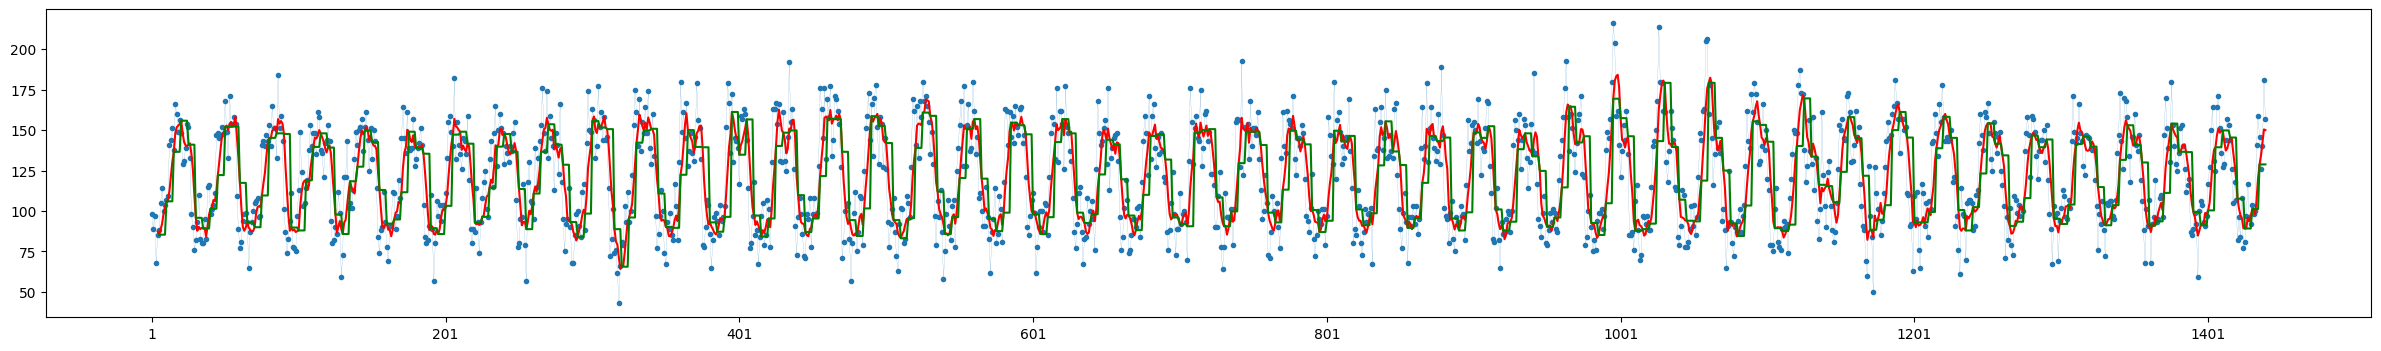

In [ ]:
moving_avg = all_req[
  all_req["day"]==1
]["f6312"].rolling(window = time_window).mean()
fixed_avg = np.repeat(
  all_req[all_req["day"]==1]["f6312"].rolling(
    window = time_window, step = time_window
  ).mean(), 
  time_window
)

_, ax = plt.subplots(figsize = (30,4))
all_req[all_req["day"]==1]["f6312"].plot(
  marker = ".", linewidth = 0.1, ax = ax
)
moving_avg.plot(color = "red", ax = ax)
fixed_avg.plot(color = "green", ax = ax)

<Axes: >

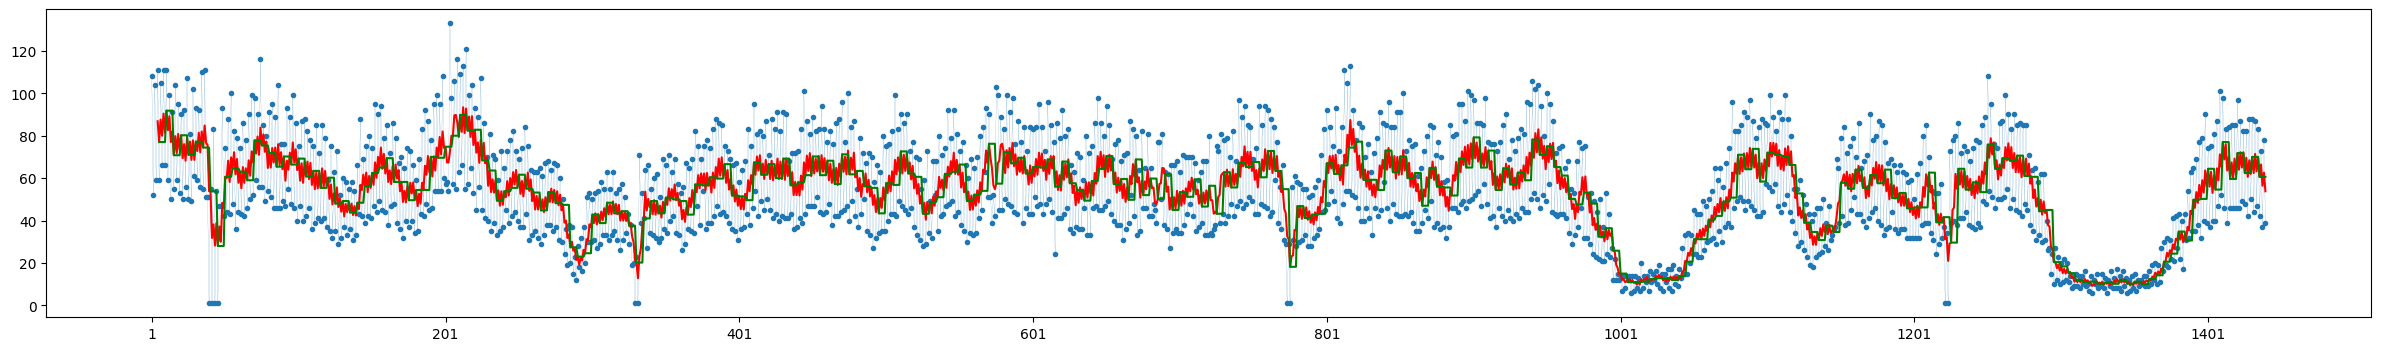

In [348]:
moving_avg = all_req[
  all_req["day"]==1
]["f6350"].rolling(window = time_window).mean()
fixed_avg = np.repeat(
  all_req[all_req["day"]==1]["f6350"].rolling(
    window = time_window, step = time_window
  ).mean(), 
  time_window
)

_, ax = plt.subplots(figsize = (30,4))
all_req[all_req["day"]==1]["f6350"].plot(
  marker = ".", linewidth = 0.1, ax = ax
)
moving_avg.plot(color = "red", ax = ax)
fixed_avg.plot(color = "green", ax = ax)

#### Error considering moving average

In [349]:
time_window = 5
all_errors = pd.DataFrame()
all_req = pd.DataFrame()
all_moving_avg = pd.DataFrame()
for day in range(1,15):#list(range(1,6)) + list(range(8,13)):
  req = alldays_functions_df.loc[
    alldays_functions_df["DAY"] == day, [str(m) for m in range(1,1441)]
  ].transpose()
  req.columns = [f"f{f}" for f in range(len(req.columns))]
  # req_stat = req.describe().transpose()
  # valid_functions = req_stat[
  #   (req_stat["std"] < 500) & (req_stat["mean"] < 1000) & (req_stat["mean"] > 10)
  # ].index
  # req = req.loc[:,valid_functions] + 1
  req += 1
  moving_avg_df = req.rolling(window = time_window, min_periods = 0).mean()
  errors = {
    "function": [],
    "rmse": [],
    "mae": [],
    "mape": [],
    "mupe": []
    # "cv": []
  }
  for f in req:
    errors["function"].append(f)
    errors["rmse"].append(
      ((req[f].values - moving_avg_df[f].values) ** 2).mean() ** 0.5
    )
    errors["mae"].append(
      abs(req[f].values - moving_avg_df[f].values).mean()
    )
    errors["mape"].append(
      (abs(req[f].values - moving_avg_df[f].values) / req[f].values).mean()
    )
    errors["mupe"].append(
      (np.array(
        [max(r - a, 0) for r, a in zip(req[f].values,moving_avg_df[f].values)]
      ) / req[f].values).mean()
    )
    # errors["cv"].append(
    #   errors["rmse"][-1] / fixed_avg_df[f].values
    # )
  errors = pd.DataFrame(errors)
  errors["day"] = day
  all_errors = pd.concat([errors, all_errors], ignore_index = True)
  moving_avg_df["day"] = day
  all_moving_avg = pd.concat([all_moving_avg, moving_avg_df])
  req["day"] = day
  all_req = pd.concat([all_req, req])
all_errors

,function,rmse,mae,mape,mupe,day
0,f0,0.023570,0.001111,0.000833,0.000278,14
1,f1,0.227547,0.055000,0.038007,0.010507,14
2,f2,0.207739,0.081725,0.061146,0.019838,14
3,f3,0.399780,0.319664,0.239711,0.079954,14
4,f4,1.268836,0.123889,0.075543,0.013598,14
...,...,...,...,...,...,...
89385,f6380,0.399861,0.319444,0.239444,0.080000,1
89386,f6381,1.068696,0.783056,0.412053,0.101370,1
89387,f6382,0.471405,0.111111,0.066667,0.011111,1
89388,f6383,0.346354,0.299919,0.225127,0.074792,1


In [350]:
all_errors = all_errors.groupby("function").mean()
all_errors

,rmse,mae,mape,mupe,day
function,,,,,
f0,0.023570,0.001111,0.000833,0.000278,7.5
f1,1.412702,0.748347,0.271715,0.061124,7.5
f10,0.459690,0.195790,0.124199,0.032249,7.5
f100,0.976540,0.805017,0.525274,0.123056,7.5
f1000,1.496375,0.712480,0.341339,0.064578,7.5
...,...,...,...,...,...
f995,0.207616,0.063651,0.044766,0.012941,7.5
f996,3.825593,2.827170,0.373206,0.095494,7.5
f997,0.308582,0.178907,0.133477,0.043578,7.5


In [351]:
print(all_errors.describe())

print("---")
above_30 = all_errors[all_errors["mape"] <= 0.3]
print(f"MAPE: {len(above_30) / len(all_errors) * 100}%")

print("---")
above_30 = all_errors[all_errors["mupe"] <= 0.3]
print(f"MUPE: {len(above_30) / len(all_errors) * 100}%")

              rmse          mae         mape         mupe     day
count  6385.000000  6385.000000  6385.000000  6385.000000  6385.0
mean      4.075352     2.126663     0.319096     0.035438     7.5
std      43.735912    29.056339     3.753104     0.039724     0.0
min       0.000000     0.000000     0.000000     0.000000     7.5
25%       0.110290     0.017129     0.010644     0.002686     7.5
50%       0.346468     0.117704     0.072580     0.016236     7.5
75%       0.883895     0.459227     0.239983     0.067755     7.5
max    2421.572695  1661.095966   180.094094     0.211824     7.5
---
MAPE: 80.98668754894284%
---
MUPE: 100.0%


#### Error considering 75th percentile

In [374]:
time_window = 5
all_errors = pd.DataFrame()
all_req = pd.DataFrame()
all_75p = pd.DataFrame()
for day in range(1,15):#list(range(1,6)) + list(range(8,13)):
  req = alldays_functions_df.loc[
    alldays_functions_df["DAY"] == day, [str(m) for m in range(1,1441)]
  ].transpose()
  req.columns = [f"f{f}" for f in range(len(req.columns))]
  # req_stat = req.describe().transpose()
  # valid_functions = req_stat[
  #   (req_stat["std"] < 500) & (req_stat["mean"] < 1000) & (req_stat["mean"] > 10)
  # ].index
  # req = req.loc[:,valid_functions] + 1
  req += 1
  fixed_p75_df = pd.DataFrame({
    funct: np.repeat(
      req[funct].rolling(
        window = time_window, step = time_window, min_periods = 0
      ).quantile(0.75), time_window
    ) for funct in req
  })
  fixed_p75_df.index = range(1, len(fixed_p75_df) + 1)
  errors = {
    "function": [],
    "rmse": [],
    "mae": [],
    "mape": [],
    "mupe": [],
    # "cv": []
  }
  for f in req:
    errors["function"].append(f)
    errors["rmse"].append(
      ((req[f].values - fixed_p75_df[f].values) ** 2).mean() ** 0.5
    )
    errors["mae"].append(
      abs(req[f].values - fixed_p75_df[f].values).mean()
    )
    errors["mape"].append(
      (abs(req[f].values - fixed_p75_df[f].values) / req[f].values).mean()
    )
    errors["mupe"].append(
      (np.array(
        [max(r - a, 0) for r, a in zip(req[f].values,fixed_p75_df[f].values)]
      ) / req[f].values).mean()
    )
    # errors["cv"].append(
    #   errors["rmse"][-1] / fixed_avg_df[f].values
    # )
  errors = pd.DataFrame(errors)
  errors["day"] = day
  all_errors = pd.concat([errors, all_errors], ignore_index = True)
  fixed_p75_df["day"] = day
  all_75p = pd.concat([all_75p, fixed_p75_df])
  req["day"] = day
  all_req = pd.concat([all_req, req])
all_errors

,function,rmse,mae,mape,mupe,day
0,f0,0.026352,0.000694,0.000347,0.000347,14
1,f1,0.367045,0.084722,0.061331,0.014803,14
2,f2,0.276385,0.073611,0.047454,0.025231,14
3,f3,0.447214,0.200000,0.100000,0.100000,14
4,f4,1.408555,0.100694,0.039789,0.017567,14
...,...,...,...,...,...,...
89385,f6380,0.447214,0.200000,0.100000,0.100000,1
89386,f6381,1.469836,1.035417,0.610906,0.080351,1
89387,f6382,0.527046,0.069444,0.013889,0.013889,1
89388,f6383,0.547723,0.300000,0.225000,0.075000,1


In [375]:
all_errors = all_errors.groupby("function").mean()
all_errors

,rmse,mae,mape,mupe,day
function,,,,,
f0,0.026352,0.000694,0.000347,0.000347,7.5
f1,2.097990,1.082937,0.437793,0.058196,7.5
f10,0.636073,0.255605,0.175031,0.031167,7.5
f100,1.030882,0.708085,0.459206,0.088422,7.5
f1000,2.101803,0.941220,0.466194,0.068438,7.5
...,...,...,...,...,...
f995,0.238972,0.044246,0.020771,0.016033,7.5
f996,5.098100,3.732242,0.567100,0.067739,7.5
f997,0.366129,0.127133,0.070941,0.053877,7.5


In [376]:
print(all_errors.describe())

print("---")
below_30 = all_errors[all_errors["mape"] <= 0.3]
print(f"MAPE: {len(below_30) / len(all_errors) * 100}%")

print("---")
below_30 = all_errors[all_errors["mupe"] <= 0.3]
print(f"MUPE: {len(below_30) / len(all_errors) * 100}%")

              rmse          mae         mape         mupe     day
count  6385.000000  6385.000000  6385.000000  6385.000000  6385.0
mean      5.967695     2.998807     0.535605     0.033126     7.5
std      61.553940    41.450232    10.292153     0.037322     0.0
min       0.000000     0.000000     0.000000     0.000000     7.5
25%       0.132159     0.014831     0.007957     0.002766     7.5
50%       0.447379     0.115179     0.056746     0.016884     7.5
75%       1.204871     0.568155     0.261514     0.055863     7.5
max    2858.795203  1991.375397   486.827694     0.306749     7.5
---
MAPE: 76.85199686765858%
---
MUPE: 99.98433829287391%


<Axes: >

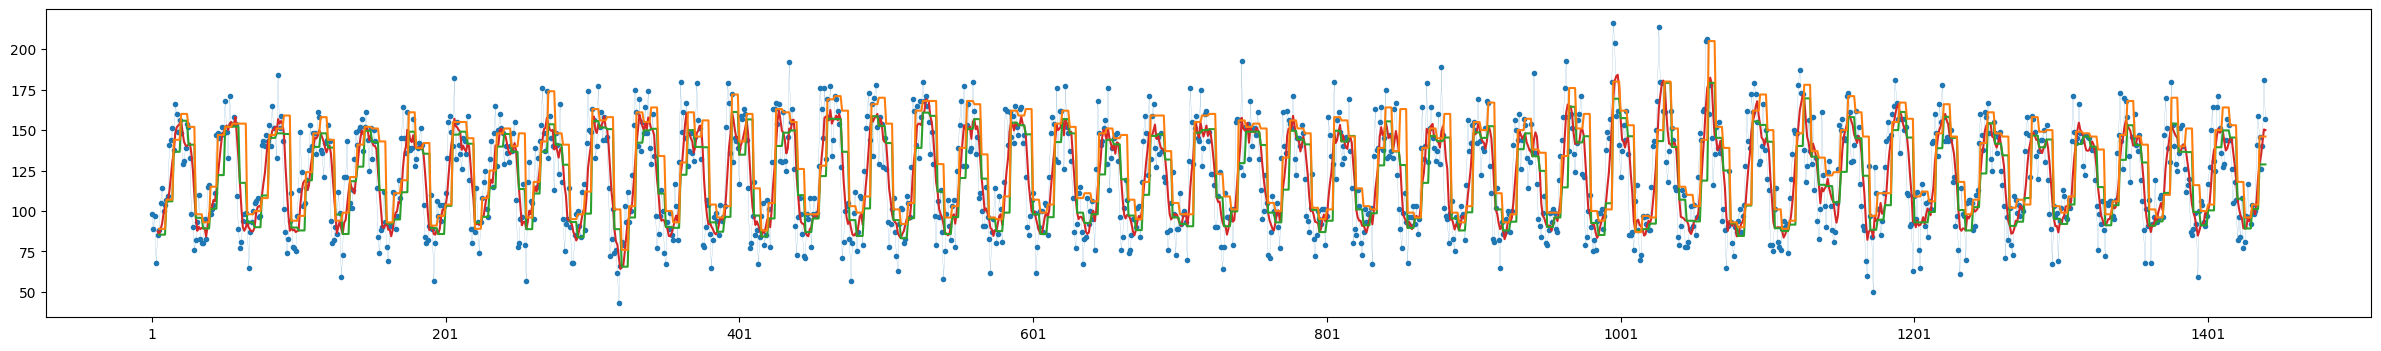

In [355]:
moving_avg = all_req[
  all_req["day"]==1
]["f6312"].rolling(window = time_window).mean()
fixed_avg = np.repeat(
  all_req[all_req["day"]==1]["f6312"].rolling(
    window = time_window, step = time_window
  ).mean(), 
  time_window
)
fixed_75p = np.repeat(
  all_req[all_req["day"]==1]["f6312"].rolling(
    window = time_window, step = time_window
  ).quantile(0.75), 
  time_window
)

_, ax = plt.subplots(figsize = (30,4))
all_req[all_req["day"]==1]["f6312"].plot(
  marker = ".", linewidth = 0.1, ax = ax
)
moving_avg.plot(color = mcolors.TABLEAU_COLORS["tab:red"], ax = ax)
fixed_avg.plot(color = mcolors.TABLEAU_COLORS["tab:green"], ax = ax)
fixed_75p.plot(color = mcolors.TABLEAU_COLORS["tab:orange"], ax = ax)

Text(0, 0.5, 'Workload [req/min]')

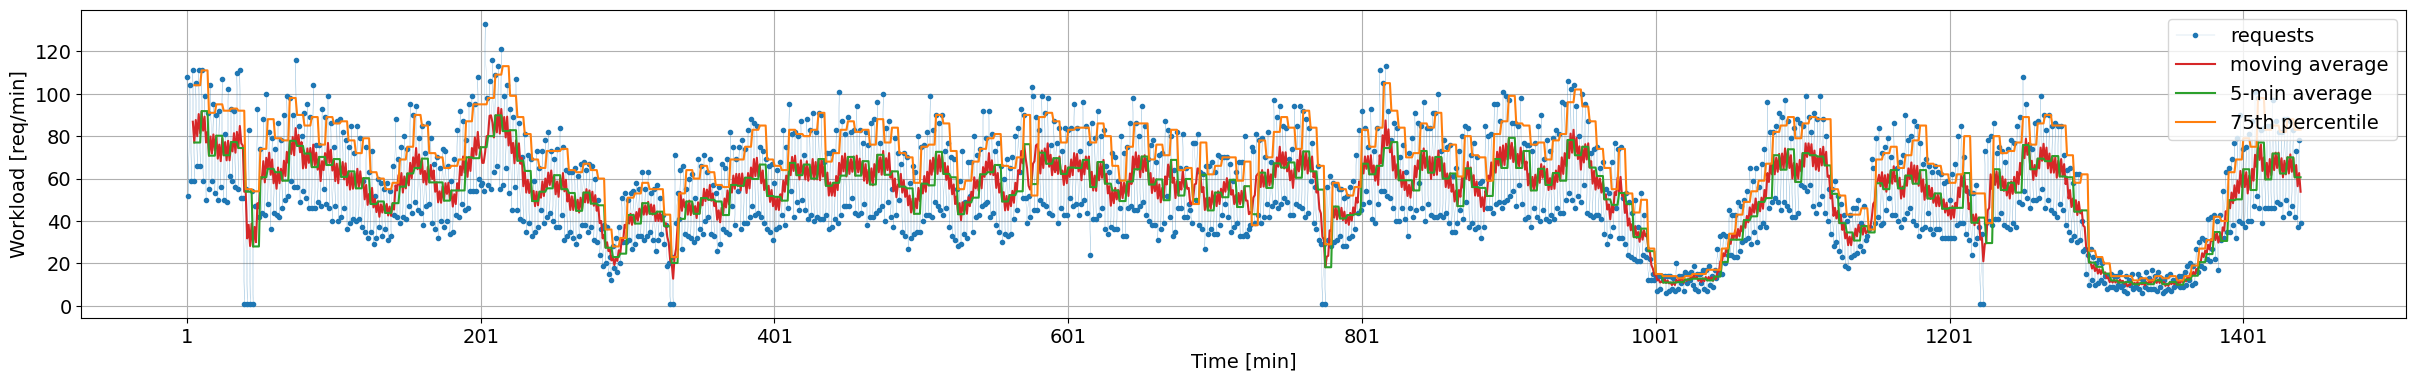

In [367]:
moving_avg = all_req[
  all_req["day"]==1
]["f6350"].rolling(window = time_window).mean()
fixed_avg = np.repeat(
  all_req[all_req["day"]==1]["f6350"].rolling(
    window = time_window, step = time_window
  ).mean(), 
  time_window
)
fixed_75p = np.repeat(
  all_req[all_req["day"]==1]["f6350"].rolling(
    window = time_window, step = time_window
  ).quantile(0.75), 
  time_window
)

_, ax = plt.subplots(figsize = (30,4))
all_req[all_req["day"]==1]["f6350"].plot(
  marker = ".", 
  linewidth = 0.1, 
  ax = ax, 
  grid = True, 
  fontsize = 14,
  label = "requests"
)
moving_avg.plot(
  color = mcolors.TABLEAU_COLORS["tab:red"], 
  ax = ax, 
  grid = True, 
  fontsize = 14,
  label = "moving average"
)
fixed_avg.plot(
  color = mcolors.TABLEAU_COLORS["tab:green"], 
  ax = ax, 
  grid = True, 
  fontsize = 14,
  label = "5-min average"
)
fixed_75p.plot(
  color = mcolors.TABLEAU_COLORS["tab:orange"], 
  ax = ax, 
  grid = True, 
  fontsize = 14,
  label = "75th percentile"
)
ax.legend(fontsize = 14)
ax.set_xlabel("Time [min]", fontsize = 14)
ax.set_ylabel("Workload [req/min]", fontsize = 14)

In [362]:
all_errors[all_errors["mupe"]>0.3]

,rmse,mae,mape,mupe,day
function,,,,,
f4809,28.016405,24.611706,14.973841,0.306749,7.5


<Axes: >

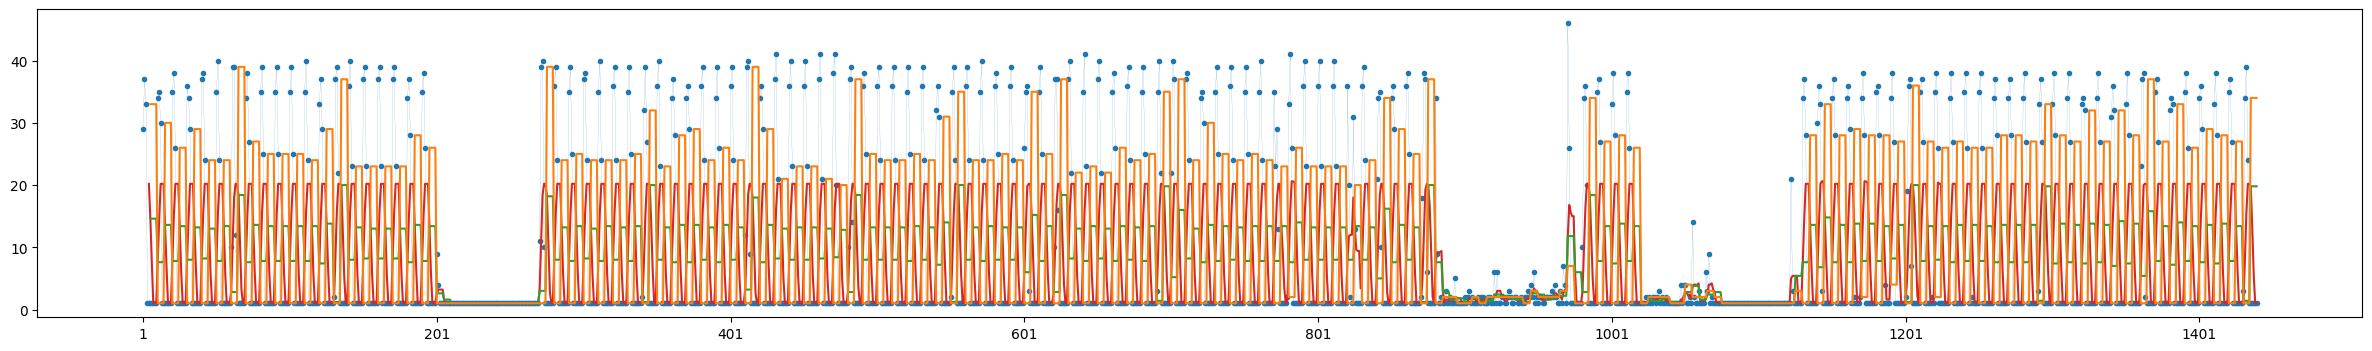

In [363]:
moving_avg = all_req[
  all_req["day"]==1
]["f4809"].rolling(window = time_window).mean()
fixed_avg = np.repeat(
  all_req[all_req["day"]==1]["f4809"].rolling(
    window = time_window, step = time_window
  ).mean(), 
  time_window
)
fixed_75p = np.repeat(
  all_req[all_req["day"]==1]["f4809"].rolling(
    window = time_window, step = time_window
  ).quantile(0.75), 
  time_window
)

_, ax = plt.subplots(figsize = (30,4))
all_req[all_req["day"]==1]["f4809"].plot(
  marker = ".", linewidth = 0.1, ax = ax
)
moving_avg.plot(color = mcolors.TABLEAU_COLORS["tab:red"], ax = ax)
fixed_avg.plot(color = mcolors.TABLEAU_COLORS["tab:green"], ax = ax)
fixed_75p.plot(color = mcolors.TABLEAU_COLORS["tab:orange"], ax = ax)